# Imports and how to use my notebook

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

DATA_DIR = Path.cwd()
print(DATA_DIR)

# cwd = current working directory. 
# DATA_DIR is a variable that stores the current working directory as a Path object.

# When sharing the code others can run it on their machine without changing the path.
# Path.cwd() automatically finds their current folder


/Users/dinareitan/Coding/BBS


**How to use my notebook**

**Structure:** the Data Description and the Case Study contain several questions and tasks for each section and stage. The markdowns are used for strucutre and follow the numbering of the tasks:

- The data on my desk consist of a check of every file before I use it
- Data description: Exhibits 1–4 and Close the briefing
- Case study: Section 2, Stages 1–7 and section 13 assumptions and limitations

Each part has short comments, both for me while working on the task and for you as a reader. They explain what I found and how I use it later, since many steps build on the results of the previous one.

After the presentation I made some changes based on the feedback given to the groups.

The charts use the same colours as the presentation. We chose colours that match the Ostrom web page, so the presentation looked like a clear commercial recommendation, as the assessment guide asks for. The three strategies have the same colour: UNHEDGED turquoise, COARSE_CAL dark blue and GRANULAR orange.

# Exhibits

## 1. The data on my desk

Before starting the exhibits, I check every file to see what I am working with. The purpose is to see if anything needs cleaning and if there are abnormalities to keep in mind. 

In [2]:
# where the data comes from (observed = public data, synthetic = constructed for the case)
print(pd.read_csv(DATA_DIR / "sources.csv"))

                                       dataset                      publisher  \
0                                Berlin SLP HB          Stromnetz Berlin GmbH   
1                                Berlin SLP GB          Stromnetz Berlin GmbH   
2                                Berlin SLP LB          Stromnetz Berlin GmbH   
3  Day-Ahead price and historical shape inputs   Bundesnetzagentur | SMARD.de   
4                        Quality-assured reBAP  Netztransparenz / German TSOs   
5                    Teaching futures snapshot      HTW Summer School project   
6               Teaching actual portfolio load      HTW Summer School project   

      status                                                url  
0   observed  https://www.stromnetz.berlin/files/globalasset...  
1   observed  https://www.stromnetz.berlin/files/globalasset...  
2   observed  https://www.stromnetz.berlin/files/globalasset...  
3   observed  https://www.smard.de/app/chart_data/4169/DE/in...  
4   observed  https:/

### slp_profiles.csv

In [3]:
# load the standard load profiles
slp = pd.read_csv(DATA_DIR / "slp_profiles.csv")

# number of rows and columns
print("Shape:", slp.shape)

# first rows, to see what the data looks like
print("\nFirst rows:")
print(slp.head())

# data type of each column
print("\nData types:")
print(slp.dtypes)

# number of missing values per column
print("\nMissing values:")
print(slp.isna().sum())

# number of timestamps that appear more than once
print("\nDuplicate timestamps:", slp["timestamp_utc"].duplicated().sum())

# min, max, mean and spread of the numbers, rounded to 2 decimal places
print("\nSummary statistics:")
print(slp.describe().round(2))

# annual sum of each profile
print("\nAnnual sums (kWh):")
print(slp[["hb_normalized_kwh", "gb_normalized_kwh", "lb_normalized_kwh"]].sum())

# count quarter-hours per local day, and show the days that do not have 96
slp["timestamp_local"] = pd.to_datetime(slp["timestamp_local"], utc=True).dt.tz_convert("Europe/Berlin")
day_counts = slp["timestamp_local"].dt.date.value_counts()
print("\nDays without 96 quarter-hours:")
print(day_counts[day_counts != 96])

Shape: (35136, 5)

First rows:
          timestamp_utc            timestamp_local  hb_normalized_kwh  \
0  2023-12-31T23:00:00Z  2024-01-01T00:00:00+01:00             27.110   
1  2023-12-31T23:15:00Z  2024-01-01T00:15:00+01:00             25.127   
2  2023-12-31T23:30:00Z  2024-01-01T00:30:00+01:00             23.237   
3  2023-12-31T23:45:00Z  2024-01-01T00:45:00+01:00             21.409   
4  2024-01-01T00:00:00Z  2024-01-01T01:00:00+01:00             19.643   

   gb_normalized_kwh  lb_normalized_kwh  
0             15.705             17.028  
1             15.158             16.454  
2             14.636             16.030  
3             14.164             15.706  
4             13.741             15.482  

Data types:
timestamp_utc         object
timestamp_local       object
hb_normalized_kwh    float64
gb_normalized_kwh    float64
lb_normalized_kwh    float64
dtype: object

Missing values:
timestamp_utc        0
timestamp_local      0
hb_normalized_kwh    0
gb_normalized_kwh   

- All 3 profiles are positive and sum to 1 000 000 kWh per year, as the data dictionary says. 
- That is why they share the same average (1 000 000 / 35 136 = 28.46 kWh).
- 31 March has 92 quarter-hours and 27 October has 100 due to changes between summer and winter time. The data is correct, but I must remember this when grouping by day.

### futures_prices.csv

In [4]:
# load the futures snapshot
futures = pd.read_csv(DATA_DIR / "futures_prices.csv")

# number of rows and columns
print("Shape:", futures.shape)

# the file is smaller, so print all rows
print("\nAll rows:")
print(futures)

# data type of each column
print("\nData types:")
print(futures.dtypes)

# number of missing values per column
print("\nMissing values:")
print(futures.isna().sum())

# number of products (period + Base/Peak) that appear more than once
print("\nDuplicate products:", futures.duplicated(["delivery_period", "load_type"]).sum())

# min, max, mean and spread of price and market activity, rounded to 2 decimals
print("\nSummary statistics:")
print(futures[["price_eur_mwh", "market_activity"]].describe().round(2))

Shape: (34, 9)

All rows:
    quote_date  delivery_year load_type product_type delivery_period  \
0   2023-09-29           2024      BASE         YEAR             CAL   
1   2023-09-29           2024      PEAK         YEAR             CAL   
2   2023-09-29           2024      BASE      QUARTER              Q1   
3   2023-09-29           2024      PEAK      QUARTER              Q1   
4   2023-09-29           2024      BASE      QUARTER              Q2   
5   2023-09-29           2024      PEAK      QUARTER              Q2   
6   2023-09-29           2024      BASE      QUARTER              Q3   
7   2023-09-29           2024      PEAK      QUARTER              Q3   
8   2023-09-29           2024      BASE      QUARTER              Q4   
9   2023-09-29           2024      PEAK      QUARTER              Q4   
10  2023-09-29           2024      BASE        MONTH             M01   
11  2023-09-29           2024      PEAK        MONTH             M01   
12  2023-09-29           2024      BAS

- There are 17 delivery periods (CAL, Q1–Q4, M01–M12) each with a Base and a Peak price all quoted on 29.09.2023 for delivery in 2024.
- Prices look realistic (49.47–159.75 EUR/MWh).
- market_activity is very skewed (median 9, max 5 000) meaning some products are traded much more than others. Relevant for exhibit 2.

### shape_factors.csv

In [5]:
# load the historical shape factors
shape = pd.read_csv(DATA_DIR / "shape_factors.csv")

# number of rows and columns
print("Shape:", shape.shape)

# first 8 rows (2 hours), to see how the factor fits the quarter-hours
print("\nFirst rows:")
print(shape.head(8))

# data type of each column
print("\nData types:")
print(shape.dtypes)

# number of missing values per column
print("\nMissing values:")
print(shape.isna().sum())

# number of timestamps that appear more than once
print("\nDuplicate timestamps:", shape["timestamp_utc"].duplicated().sum())

# min, max, mean and spread of all number columns, rounded to 2 decimals
print("\nSummary statistics:")
print(shape.describe().round(2))

# average shape factor over the whole year
print("\nAverage shape factor:", round(shape["historical_shape_factor"].mean(), 4))

# check that is_peak follows the peak definition: 
# monday-friday 08:00-20:00 local time
local_time = pd.to_datetime(shape["timestamp_local"], utc=True).dt.tz_convert("Europe/Berlin")
peak_rule = (local_time.dt.weekday < 5) & (local_time.dt.hour >= 8) & (local_time.dt.hour < 20)
print("\nis_peak follows Mon-Fri 08-20:", (peak_rule.astype(int) == shape["is_peak"]).all())

Shape: (35136, 7)

First rows:
          timestamp_utc            timestamp_local  month  hour  weekday  \
0  2023-12-31T23:00:00Z  2024-01-01T00:00:00+01:00      1     0        0   
1  2023-12-31T23:15:00Z  2024-01-01T00:15:00+01:00      1     0        0   
2  2023-12-31T23:30:00Z  2024-01-01T00:30:00+01:00      1     0        0   
3  2023-12-31T23:45:00Z  2024-01-01T00:45:00+01:00      1     0        0   
4  2024-01-01T00:00:00Z  2024-01-01T01:00:00+01:00      1     1        0   
5  2024-01-01T00:15:00Z  2024-01-01T01:15:00+01:00      1     1        0   
6  2024-01-01T00:30:00Z  2024-01-01T01:30:00+01:00      1     1        0   
7  2024-01-01T00:45:00Z  2024-01-01T01:45:00+01:00      1     1        0   

   is_peak  historical_shape_factor  
0        0                 0.832554  
1        0                 0.832554  
2        0                 0.832554  
3        0                 0.832554  
4        0                 0.796187  
5        0                 0.796187  
6        0        

- The factor is an hourly value repeated over the 4 quarter-hours. 
- Weekday uses monday = 0. 
- is_peak = 1 follows the peak definition
- The average factor is 1, so it is a relative shape, not a price. 
- All factors are positive, which matters because the futures price is multiplied by the factor to build the HPFC.

### day_ahead_prices.csv

In [6]:
# load the realised day-ahead prices
day_ahead = pd.read_csv(DATA_DIR / "day_ahead_prices.csv")

# number of rows and columns
print("Shape:", day_ahead.shape)

# first 8 rows (2 hours), to see how the hourly price fits the quarter-hours
print("\nFirst rows:")
print(day_ahead.head(8))

# data type of each column
print("\nData types:")
print(day_ahead.dtypes)

# number of missing values per column
print("\nMissing values:")
print(day_ahead.isna().sum())

# number of timestamps that appear more than once
print("\nDuplicate timestamps:", day_ahead["timestamp_utc"].duplicated().sum())

# min, max, mean and spread, rounded to 2 decimals
print("\nSummary statistics:")
print(day_ahead.describe().round(2))

# check that the price is the same in all 4 quarter-hours of each hour
# reshape puts the 4 quarter-hours of each hour on one row
prices_by_hour = day_ahead["day_ahead_price_eur_mwh"].values.reshape(-1, 4)
print("\nSame price in all 4 quarter-hours of every hour:", (prices_by_hour.max(axis=1) == prices_by_hour.min(axis=1)).all())

Shape: (35136, 3)

First rows:
          timestamp_utc            timestamp_local  day_ahead_price_eur_mwh
0  2023-12-31T23:00:00Z  2024-01-01T00:00:00+01:00                     0.10
1  2023-12-31T23:15:00Z  2024-01-01T00:15:00+01:00                     0.10
2  2023-12-31T23:30:00Z  2024-01-01T00:30:00+01:00                     0.10
3  2023-12-31T23:45:00Z  2024-01-01T00:45:00+01:00                     0.10
4  2024-01-01T00:00:00Z  2024-01-01T01:00:00+01:00                     0.01
5  2024-01-01T00:15:00Z  2024-01-01T01:15:00+01:00                     0.01
6  2024-01-01T00:30:00Z  2024-01-01T01:30:00+01:00                     0.01
7  2024-01-01T00:45:00Z  2024-01-01T01:45:00+01:00                     0.01

Data types:
timestamp_utc               object
timestamp_local             object
day_ahead_price_eur_mwh    float64
dtype: object

Missing values:
timestamp_utc              0
timestamp_local            0
day_ahead_price_eur_mwh    0
dtype: int64

Duplicate timestamps: 0

Summary st

- Hourly price repeated over the 4 quarter-hours
- Mean and median are close (78.51 vs 79.59 EUR/MWh)
- Prices range from −135.45 to 936.28 EUR/MWh. 
- Negative prices and spikes are real market outcomes

### actual_portfolio_load.csv

In [7]:
# load the realised customer consumption
actual_load = pd.read_csv(DATA_DIR / "actual_portfolio_load.csv")

# number of rows and columns
print("Shape:", actual_load.shape)

# first rows
print("\nFirst rows:")
print(actual_load.head())

# data type of each column
print("\nData types:")
print(actual_load.dtypes)

# number of missing values per column
print("\nMissing values:")
print(actual_load.isna().sum())

# number of timestamps that appear more than once
print("\nDuplicate timestamps:", actual_load["timestamp_utc"].duplicated().sum())

# min, max, mean and spread, rounded to 2 decimals
print("\nSummary statistics:")
print(actual_load.describe().round(2))

# annual energy per group and in total (MWh)
print("\nAnnual sums (MWh):")
print(actual_load[["hb_actual_mwh", "gb_actual_mwh", "lb_actual_mwh", "total_actual_mwh"]].sum().round(2))

Shape: (35136, 6)

First rows:
          timestamp_utc            timestamp_local  hb_actual_mwh  \
0  2023-12-31T23:00:00Z  2024-01-01T00:00:00+01:00       0.963811   
1  2023-12-31T23:15:00Z  2024-01-01T00:15:00+01:00       0.892288   
2  2023-12-31T23:30:00Z  2024-01-01T00:30:00+01:00       0.825399   
3  2023-12-31T23:45:00Z  2024-01-01T00:45:00+01:00       0.762168   
4  2024-01-01T00:00:00Z  2024-01-01T01:00:00+01:00       0.700484   

   gb_actual_mwh  lb_actual_mwh  total_actual_mwh  
0       0.095269       0.034711          1.093791  
1       0.091538       0.034484          1.018309  
2       0.088031       0.033877          0.947307  
3       0.085013       0.033571          0.880752  
4       0.080490       0.032411          0.813385  

Data types:
timestamp_utc        object
timestamp_local      object
hb_actual_mwh       float64
gb_actual_mwh       float64
lb_actual_mwh       float64
total_actual_mwh    float64
dtype: object

Missing values:
timestamp_utc       0
timestam

- All values are positive.
- The annual sums (43 138 MWh) are close to the customer table (43 000 MWh). 
- I will use the 138 MWh difference in stage 5. 

### imbalance_prices.csv

In [8]:
# load the realised imbalance prices (reBAP)
imbalance = pd.read_csv(DATA_DIR / "imbalance_prices.csv")

# number of rows and columns
print("Shape:", imbalance.shape)

# first 8 rows (2 hours), to compare with day-ahead
print("\nFirst rows:")
print(imbalance.head(8))

# data type of each column
print("\nData types:")
print(imbalance.dtypes)

# number of missing values per column
print("\nMissing values:")
print(imbalance.isna().sum())

# number of timestamps that appear more than once
print("\nDuplicate timestamps:", imbalance["timestamp_utc"].duplicated().sum())

# min, max, mean and spread, rounded to 2 decimals
print("\nSummary statistics:")
print(imbalance.describe().round(2))

Shape: (35136, 3)

First rows:
          timestamp_utc            timestamp_local  imbalance_price_eur_mwh
0  2023-12-31T23:00:00Z  2024-01-01T00:00:00+01:00                    75.15
1  2023-12-31T23:15:00Z  2024-01-01T00:15:00+01:00                    78.53
2  2023-12-31T23:30:00Z  2024-01-01T00:30:00+01:00                    83.17
3  2023-12-31T23:45:00Z  2024-01-01T00:45:00+01:00                    75.15
4  2024-01-01T00:00:00Z  2024-01-01T01:00:00+01:00                    79.13
5  2024-01-01T00:15:00Z  2024-01-01T01:15:00+01:00                    80.89
6  2024-01-01T00:30:00Z  2024-01-01T01:30:00+01:00                    75.15
7  2024-01-01T00:45:00Z  2024-01-01T01:45:00+01:00                    75.15

Data types:
timestamp_utc               object
timestamp_local             object
imbalance_price_eur_mwh    float64
dtype: object

Missing values:
timestamp_utc              0
timestamp_local            0
imbalance_price_eur_mwh    0
dtype: int64

Duplicate timestamps: 0

Summary st

- The reBAP changes every 15 minutes, unlike day-ahead
- The average level is close to day-ahead (85.77 vs 78.51 EUR/MWh)
- reBAP varies about 5 times more and the middle 50 % is wider.
- Extreme values in both directions.
- Imbalance prices will be used in exhibit 4.

### Conclusion of the data check

- All time series (slp, shape, day-ahead, actual and imbalance) have one row per quarter-hour in 2024 (366 * 96 = 35 136) on the timestamps
- No missing values
- No duplicates
- No cleaning is needed. The only preprocessing is converting the timestamps from text to datetime
- Negative and extreme prices are kept because they are real market data. 

### Converting timestamps to datetime

In [9]:
# Convert timestamp text to datetime in all time-series files
# UTC is used as the join key and local Berlin time is used to read daily and weekly patterns

# the five files that have timestamps (futures_prices.csv only has dates)
time_series = [slp, shape, day_ahead, imbalance, actual_load]

for i in range(len(time_series)):
    # pick one table from the list
    df = time_series[i]
    # convert the UTC to datetime
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    # convert the local time to datetime
    # read as UTC first, then show in Berlin time
    df["timestamp_local"] = pd.to_datetime(df["timestamp_local"], utc=True).dt.tz_convert("Europe/Berlin")

# check that the conversion worked for one of the files
print(slp.dtypes)
print(shape.dtypes)
print(day_ahead.dtypes)
print(imbalance.dtypes)
print(actual_load.dtypes)

timestamp_utc                  datetime64[ns, UTC]
timestamp_local      datetime64[ns, Europe/Berlin]
hb_normalized_kwh                          float64
gb_normalized_kwh                          float64
lb_normalized_kwh                          float64
dtype: object
timestamp_utc                        datetime64[ns, UTC]
timestamp_local            datetime64[ns, Europe/Berlin]
month                                              int64
hour                                               int64
weekday                                            int64
is_peak                                            int64
historical_shape_factor                          float64
dtype: object
timestamp_utc                        datetime64[ns, UTC]
timestamp_local            datetime64[ns, Europe/Berlin]
day_ahead_price_eur_mwh                          float64
dtype: object
timestamp_utc                        datetime64[ns, UTC]
timestamp_local            datetime64[ns, Europe/Berlin]
imbalance_price_eur

## Exhibit 1

In [10]:
slp.head()

,timestamp_utc,timestamp_local,hb_normalized_kwh,gb_normalized_kwh,lb_normalized_kwh
0,2023-12-31 23:00:00+00:00,2024-01-01 00:00:00+01:00,27.110,15.705,17.028
1,2023-12-31 23:15:00+00:00,2024-01-01 00:15:00+01:00,25.127,15.158,16.454
2,2023-12-31 23:30:00+00:00,2024-01-01 00:30:00+01:00,23.237,14.636,16.030
3,2023-12-31 23:45:00+00:00,2024-01-01 00:45:00+01:00,21.409,14.164,15.706
4,2024-01-01 00:00:00+00:00,2024-01-01 01:00:00+01:00,19.643,13.741,15.482


### 1.1 Scaling the standard load profiles

In [11]:
# Scale each standard load profile to its customer group

# customer table from the data description section 2
groups = ["hb", "gb", "lb"]
# number of customers n_p
customers = [10000, 200, 20]  
# annual consumption per customer e_p (MWh per year)
consumption = [3.5, 30.0, 100.0]

for i in range(len(groups)):
    # annual energy of the group: E_p = n_p * e_p (MWh)
    E_p = customers[i] * consumption[i]
    # share of the years consumption in each quarter-hour (kWh / kWh -> no unit)
    share = slp[groups[i] + "_normalized_kwh"] / slp[groups[i] + "_normalized_kwh"].sum()
    # scaled load: L_p,t = E_p * share (MWh per quarter-hour)
    slp[groups[i] + "_load_mwh"] = E_p * share
    print(groups[i].upper() + ": E_p = " + str(E_p) + " MWh")

# total portfolio load in every quarter-hour: L_t = HB + GB + LB (MWh per quarter-hour)
slp["total_load_mwh"] = slp["hb_load_mwh"] + slp["gb_load_mwh"] + slp["lb_load_mwh"]

HB: E_p = 35000.0 MWh
GB: E_p = 6000.0 MWh
LB: E_p = 2000.0 MWh


The SLP columns = shape of consumption. Each profile sums to 1 000 000 kWh per year regardless of the number of customers. 

I calculated the annual energy per group and scaled each group with one factor. 
EX: HB needs 35 times the standard 1 000 MWh profile. 
Every quarter-hour is scaled with the same factor, so the shape stays the same and only the size changes. 

### 1.2 Reconciliation and annual energy share per customer group

       target_mwh  scaled_sum_mwh  difference_mwh  share_pct
HB        35000.0         35000.0             0.0      81.40
GB         6000.0          6000.0             0.0      13.95
LB         2000.0          2000.0             0.0       4.65
Total     43000.0         43000.0             0.0     100.00


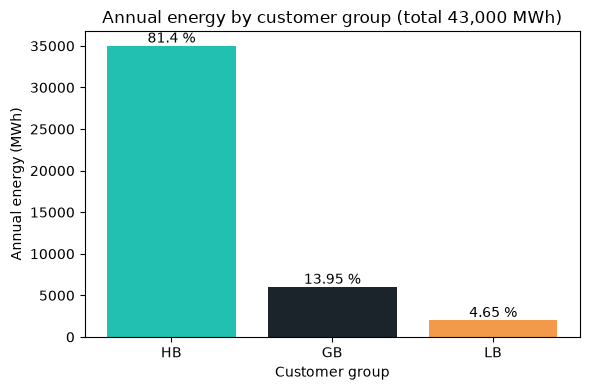

In [12]:
reconciliation = pd.DataFrame(index=["HB", "GB", "LB"])
# target from the customer table
reconciliation["target_mwh"] = [35000.0, 6000.0, 2000.0]
# annual sum of the scaled profile
reconciliation["scaled_sum_mwh"] = [slp["hb_load_mwh"].sum(), slp["gb_load_mwh"].sum(), slp["lb_load_mwh"].sum()]
# should be 0 if the scaling is correct
reconciliation["difference_mwh"] = reconciliation["scaled_sum_mwh"] - reconciliation["target_mwh"]
# share of the total portfolio energy
reconciliation["share_pct"] = reconciliation["scaled_sum_mwh"] / slp["total_load_mwh"].sum() * 100
# Adding a total row at the bottom
reconciliation.loc["Total"] = reconciliation.sum()
print(reconciliation.round(2))

# chart
# annual energy per group with the share written on each bar
# using ostrom colours for the power point
colors = ["#21C0B0", "#1B232B", "#F2994A"]
names = ["HB", "GB", "LB"]
labels = []
for i in range(len(names)):
    labels.append(str(round(reconciliation.loc[names[i], "share_pct"], 2)) + " %")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(names, reconciliation.loc[names, "scaled_sum_mwh"], color=colors)
ax.bar_label(bars, labels=labels)
ax.set_title("Annual energy by customer group (total 43,000 MWh)")
ax.set_xlabel("Customer group")
ax.set_ylabel("Annual energy (MWh)")
plt.tight_layout()
# save the figure as pdf for the report
plt.savefig("e1_energy_share.pdf", bbox_inches="tight")
plt.show()

The scaled profiles matches the customer table. 

The difference is used to check that there is no energy lost or added in the scaling. It is 0 for all groups.

HB dominates. One reason can be a much lager number of customers than GB and LB

### 1.3 Average daily HB, GB and LB shapes

        HB    GB    LB  Total
hour                         
0     2.43  0.40  0.13   2.95
1     1.81  0.35  0.12   2.28
2     1.57  0.32  0.11   2.01
3     1.50  0.32  0.11   1.93
4     1.51  0.36  0.11   1.98
5     1.73  0.40  0.12   2.24
6     2.79  0.44  0.16   3.39
7     3.91  0.60  0.27   4.77
8     4.53  0.92  0.38   5.82
9     4.84  1.09  0.37   6.30
10    4.93  1.12  0.29   6.35
11    5.16  1.16  0.30   6.61
12    5.58  1.09  0.26   6.94
13    5.28  0.95  0.21   6.44
14    4.58  0.87  0.20   5.65
15    4.13  0.89  0.20   5.22
16    3.99  0.90  0.20   5.09
17    4.53  0.90  0.25   5.69
18    5.53  0.78  0.36   6.67
19    6.26  0.60  0.41   7.26
20    5.86  0.54  0.32   6.73
21    5.17  0.51  0.23   5.91
22    4.54  0.46  0.19   5.20
23    3.47  0.43  0.16   4.06

Hour with the highest average load:
HB       19
GB       11
LB       19
Total    19
dtype: int32


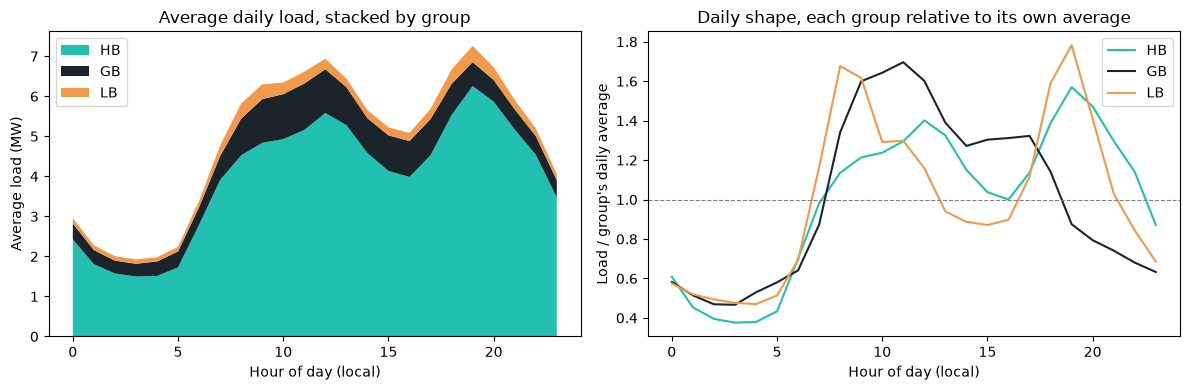

In [13]:
# Average daily shape per customer group

# hour of the day in local Berlin time (0-23)
slp["hour"] = slp["timestamp_local"].dt.hour
load_columns = ["hb_load_mwh", "gb_load_mwh", "lb_load_mwh", "total_load_mwh"]
# Go from MWh per quarter-hour to MW: multiply 4
daily_mw = slp.groupby("hour")[load_columns].mean() * 4
daily_mw.columns = ["HB", "GB", "LB", "Total"]
print(daily_mw.round(2))
print("\nHour with the highest average load:")
print(daily_mw.idxmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# left 
# stacked MW: shows how the three groups add up to the total load
axes[0].stackplot(daily_mw.index, daily_mw["HB"], daily_mw["GB"], daily_mw["LB"], labels=names, colors=colors)
axes[0].set_title("Average daily load, stacked by group")
axes[0].set_xlabel("Hour of day (local)")
axes[0].set_ylabel("Average load (MW)")
axes[0].legend(loc="upper left")
# right
# each group divided by its own daily average to compare the shapes
for i in range(len(names)):
    axes[1].plot(daily_mw.index, daily_mw[names[i]] / daily_mw[names[i]].mean(), color=colors[i], label=names[i])
axes[1].axhline(1, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("Daily shape, each group relative to its own average")
axes[1].set_xlabel("Hour of day (local)")
axes[1].set_ylabel("Load / group's daily average")
axes[1].legend()
plt.tight_layout()
# save the figure as pdf for the report
plt.savefig("e1_daily_shape.pdf", bbox_inches="tight")
plt.show()

The charts show average load in MW (MWh per quarter-hour × 4)

HB (Households) are lowest at night. The load rises in the morning to a first peak around 12:00 and dips in the afternoon before a new higher peak around 19:00

GB (Commercial) follows business hours and peeks between 09 and 13 then drops after 17:00

LB (Agriculture) have 2 peaks, one in the morning around 8 and on the evening around 19

To compare the shapes (since GB and LB have lower load than HB) the right chart show the groups relative to its own average. 

### 1.4 Weekday vs weekend consumption

       Weekday  Weekend  change_pct
HB       3.909    4.174       6.777
GB       0.749    0.516     -31.124
LB       0.229    0.226      -1.271
Total    4.887    4.916       0.590


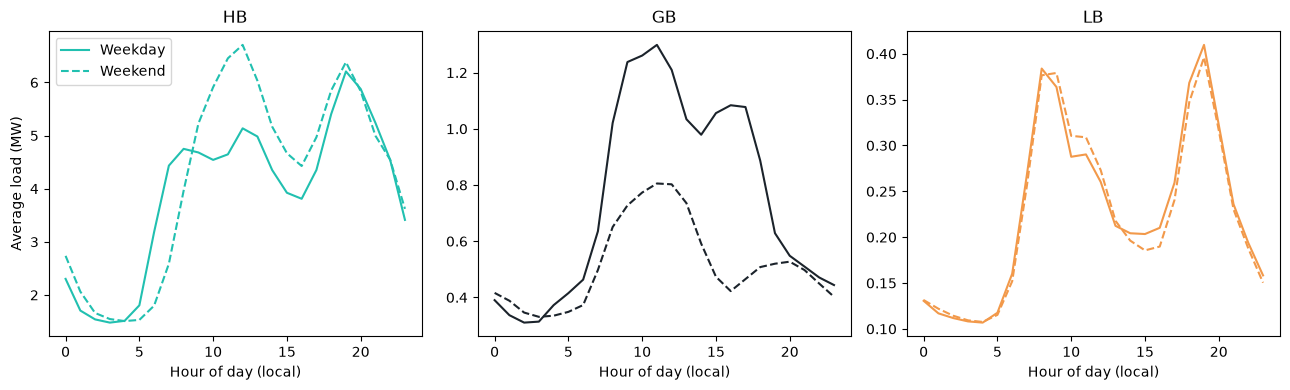

In [14]:
# weekday vs weekend

# True if the day is saturday or sunday
slp["is_weekend"] = slp["timestamp_local"].dt.weekday >= 5

# average load on weekdays and weekends in MW
week_mw = slp.groupby("is_weekend")[load_columns].mean() * 4
week_mw.index = ["Weekday", "Weekend"]
week_mw.columns = ["HB", "GB", "LB", "Total"]
# turn the table so each group is one row
week_mw = week_mw.T
# change from weekday to weekend in %
week_mw["change_pct"] = (week_mw["Weekend"] / week_mw["Weekday"] - 1) * 100
print(week_mw.round(3))

# average daily shape on weekdays and on weekends in MW
weekday_mw = slp[slp["is_weekend"] == False].groupby("hour")[load_columns].mean() * 4
weekend_mw = slp[slp["is_weekend"] == True].groupby("hour")[load_columns].mean() * 4

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i in range(len(names)):
    # solid line = weekday, dashed line = weekend
    axes[i].plot(weekday_mw.index, weekday_mw[load_columns[i]], color=colors[i], label="Weekday")
    axes[i].plot(weekend_mw.index, weekend_mw[load_columns[i]], color=colors[i], linestyle="--", label="Weekend")
    axes[i].set_title(names[i])
    axes[i].set_xlabel("Hour of day (local)")
axes[0].set_ylabel("Average load (MW)")
axes[0].legend()
plt.tight_layout()
# save figure as pdf for report
plt.savefig("e1_weekday_weekend.pdf", bbox_inches="tight")
plt.show()

The figure shows weekdays in solid line and weekend in dashed line. 

On weekends HB uses 6,8% more which seems plausible because people spend more time at home. 
GB uses 31,1% less because many businesses are closed making the business-hours block smaller on weekends. 
LB is almost the same (-1,3%). 

### 1.5 How the customer mix influences the total load shape

Because HB is 81% of the energy, the total load is quite similar to the household shape (low at night, peak in the morning, high midday and peak evening)

GB adds load during working hours on weekdays. 

On weekends, GB drops and HB increases. They almost cancel each other out with a +0,6% change from weekday to weekend. 

LB load is too small to make significant changes to the total shape

## Exhibit 2

In [15]:
futures.head()

,quote_date,delivery_year,load_type,product_type,delivery_period,delivery_start,delivery_end_exclusive,price_eur_mwh,market_activity
0,2023-09-29,2024,BASE,YEAR,CAL,2024-01-01,2025-01-01,77.26,5000
1,2023-09-29,2024,PEAK,YEAR,CAL,2024-01-01,2025-01-01,86.60,1400
2,2023-09-29,2024,BASE,QUARTER,Q1,2024-01-01,2024-04-01,66.42,3000
3,2023-09-29,2024,PEAK,QUARTER,Q1,2024-01-01,2024-04-01,77.70,840
4,2023-09-29,2024,BASE,QUARTER,Q2,2024-04-01,2024-07-01,66.23,2200


### 2.1 Base and Peak prices and market activity by delivery period

Prices (EUR/MWh):
load_type          BASE    PEAK
delivery_period                
CAL               77.26   86.60
Q1                66.42   77.70
Q2                66.23   64.76
Q3                74.74   69.07
Q4               101.39  134.42
M01               75.32   88.68
M02               60.09   70.59
M03               63.45   72.79
M04               67.11   72.56
M05               60.96   52.40
M06               79.64   80.57
M07               59.45   49.47
M08               84.80   74.16
M09               73.06   76.62
M10               91.85  111.59
M11              106.66  140.84
M12              112.07  159.75

Market activity:
load_type        BASE  PEAK
delivery_period            
CAL              5000  1400
Q1               3000   840
Q2               2200   616
Q3               1600   448
Q4               1400   392
M01               900   252
M02               800   224
M03               650   182
M04                10     3
M05                 8     2
M06                 

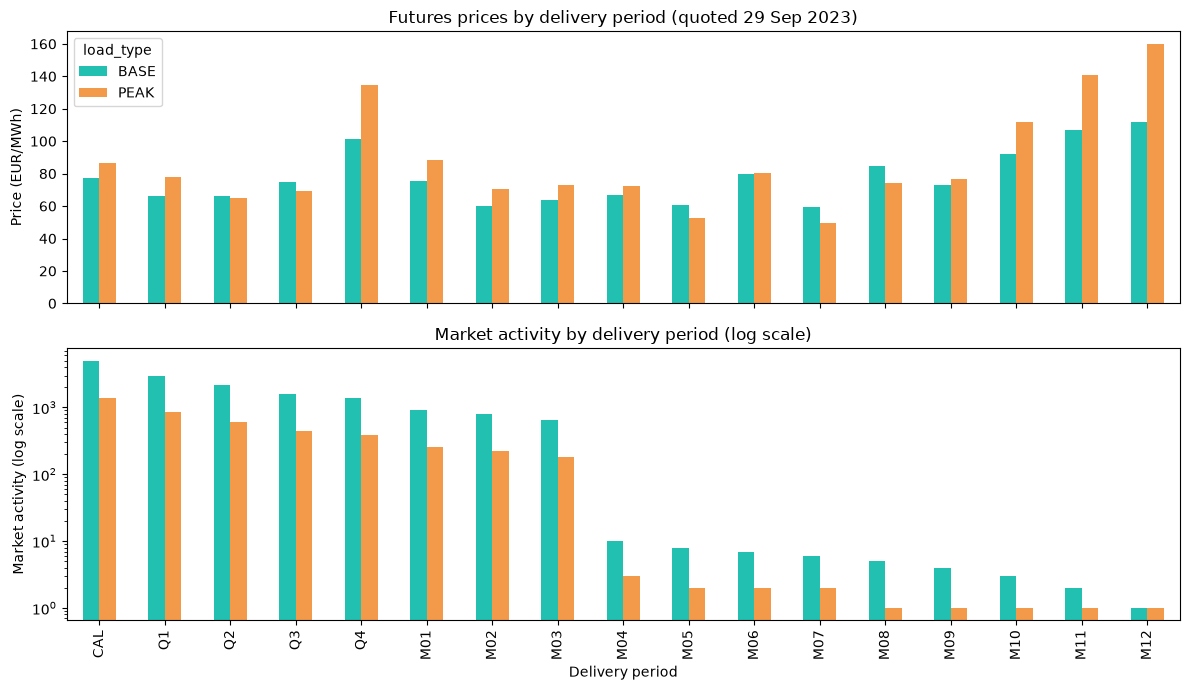

In [16]:
# Base and Peak prices and market activity by delivery period

# delivery periods in calendar order
period_order = ["CAL", "Q1", "Q2", "Q3", "Q4",
                "M01", "M02", "M03", "M04", "M05", "M06",
                "M07", "M08", "M09", "M10", "M11", "M12"]

# one row per delivery period, one column for BASE and one for PEAK
futures_prices = futures.pivot(index="delivery_period", columns="load_type", values="price_eur_mwh").reindex(period_order)
activity = futures.pivot(index="delivery_period", columns="load_type", values="market_activity").reindex(period_order)
print("Prices (EUR/MWh):")
print(futures_prices)
print("\nMarket activity:")
print(activity)

# one figure with two panels that share the same x-axis (delivery period)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
# top
# Base and Peak price
futures_prices.plot(kind="bar", ax=axes[0], color=["#21C0B0", "#F2994A"])
axes[0].set_title("Futures prices by delivery period (quoted 29 Sep 2023)")
axes[0].set_ylabel("Price (EUR/MWh)")
# bottom
# market activity on a log scale to make differences visible, can use log since values is positive
activity.plot(kind="bar", ax=axes[1], color=["#21C0B0", "#F2994A"], logy=True, legend=False)
axes[1].set_title("Market activity by delivery period (log scale)")
axes[1].set_ylabel("Market activity (log scale)")
axes[1].set_xlabel("Delivery period")
plt.tight_layout()
# save figure for report
plt.savefig("e2_prices_activity.pdf", bbox_inches="tight")
plt.show()

Top panel: Base and Peak price for each delivery period. 
Bottom: market_activity on a log scale. Activity is high for CAL and all quarters and M01–M03 and low for M4-M12

Prices are shown on a normal scale
A log scale works for market_activity because all values are positive and range from 1 to 5 000. 
Since I am working with power prices which can be negative I need to be extra careful using log. Log is not defined for zero or negative values.

### 2.2 Market activity criterion, usable and illiquid products

In [17]:
THRESHOLD = 100

# a delivery period is usable only if both its base and its peak product is over the threshold
lowest_activity = activity.min(axis=1)
usable = []
illiquid = []
for i in range(len(period_order)):
    period = period_order[i]
    if lowest_activity[period] >= THRESHOLD:
        usable.append(period)
    else:
        illiquid.append(period)
print("Usable products:  ", usable)
print("Illiquid products:", illiquid)

# check the gap
# the most active illiquid product vs the least active usable product
print("\nHighest market_activity below the threshold:", futures.loc[futures["market_activity"] < THRESHOLD, "market_activity"].max())
print("Lowest market_activity at or above the threshold:", futures.loc[futures["market_activity"] >= THRESHOLD, "market_activity"].min())

Usable products:   ['CAL', 'Q1', 'Q2', 'Q3', 'Q4', 'M01', 'M02', 'M03']
Illiquid products: ['M04', 'M05', 'M06', 'M07', 'M08', 'M09', 'M10', 'M11', 'M12']

Highest market_activity below the threshold: 10
Lowest market_activity at or above the threshold: 182


I can only use features that have enough market activity to make the price reliable. This is because the quoted price is only useful for hedging if the product can be traded. 

The chart shows a big gap. All usable products are at 182 or above and M04–M12 are at 10 or below. I choose market_activity ≥ 100 which lies inside this gap. But since the highest value below is 10 and the lowest above is 182 I could those numbers. According to the sources market activity is a synthetic and simplified indicator. The threshold and the lowest above and highest below threshold only makes sence for this dataset. With real liquidity data such as traded volume or bid–ask spreads the criterion and the threshold would have different threshold and most likely not a big gap like this. 

The hedge can use both base and peak, so a period is only usable if both products pass.

This gives me: 
- Usable: CAL, Q1, Q2, Q3, Q4, M01, M02, M03
- Illiquid: M04–M12

### 2.3 Non-overlapping ways to cover 2024


CAL:
                delivery_start delivery_end_exclusive
delivery_period                                      
CAL                 2024-01-01             2025-01-01

Q1-Q4:
                delivery_start delivery_end_exclusive
delivery_period                                      
Q1                  2024-01-01             2024-04-01
Q2                  2024-04-01             2024-07-01
Q3                  2024-07-01             2024-10-01
Q4                  2024-10-01             2025-01-01

M01-M03 + Q2-Q4:
                delivery_start delivery_end_exclusive
delivery_period                                      
M01                 2024-01-01             2024-02-01
M02                 2024-02-01             2024-03-01
M03                 2024-03-01             2024-04-01
Q2                  2024-04-01             2024-07-01
Q3                  2024-07-01             2024-10-01
Q4                  2024-10-01             2025-01-01


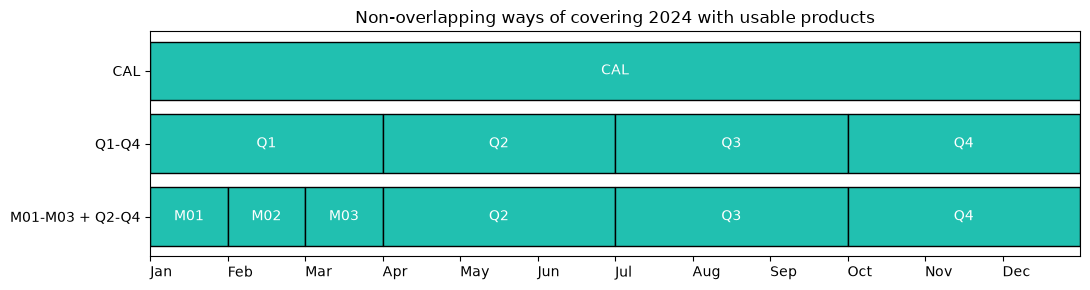

In [18]:
options = [["CAL"],
           ["Q1", "Q2", "Q3", "Q4"],
           ["M01", "M02", "M03", "Q2", "Q3", "Q4"]]
option_names = ["CAL", "Q1-Q4", "M01-M03 + Q2-Q4"]

# one row per product 
# since base and peak have same delivery dates, base is enough
base = futures[futures["load_type"] == "BASE"].set_index("delivery_period")

# delivery dates of the products in each option
for i in range(len(options)):
    print("\n" + option_names[i] + ":")
    print(base.loc[options[i], ["delivery_start", "delivery_end_exclusive"]])

# for the chart: first month and length in months of each product
start = pd.to_datetime(base["delivery_start"])
end = pd.to_datetime(base["delivery_end_exclusive"])
start_month = start.dt.month
length = (end.dt.year - start.dt.year) * 12 + (end.dt.month - start.dt.month)

# chart
# one row per option and one box per product
fig, ax = plt.subplots(figsize=(11, 3))
for i in range(len(options)):
    for product in options[i]:
        ax.barh(i, length[product], left=start_month[product] - 1, color="#21C0B0", edgecolor="black")
        ax.text(start_month[product] - 1 + length[product] / 2, i, product, ha="center", va="center", color="white")
ax.set_yticks(range(len(options)))
ax.set_yticklabels(option_names)
ax.invert_yaxis()
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], ha="left")
ax.set_xlim(0, 12)
ax.set_title("Non-overlapping ways of covering 2024 with usable products")
plt.tight_layout()
# save figure for report
plt.savefig("e2_tilings.pdf", bbox_inches="tight")
plt.show()

According to the data sets and my criterion there are 3 ways to cover 2024 with usable products and no overlap:
1) CAL alone
2) Q1-Q4
3) M01-M03 + Q2-Q4

It is important that the products cover the whole year with no overlap and gaps. So the option include products that starts on the date the previous ends and runs over the whole year. 

M01-M03 + Q2-Q4 is the finest option

### 2.4 Seasonal pattern in the futures prices

In [19]:
seasonal = futures_prices.loc[usable].copy()
# peak minus base
# positive means peak hours are more expensive than the average hour
seasonal["peak_minus_base"] = seasonal["PEAK"] - seasonal["BASE"]
print(seasonal.round(2))

load_type          BASE    PEAK  peak_minus_base
delivery_period                                 
CAL               77.26   86.60             9.34
Q1                66.42   77.70            11.28
Q2                66.23   64.76            -1.47
Q3                74.74   69.07            -5.67
Q4               101.39  134.42            33.03
M01               75.32   88.68            13.36
M02               60.09   70.59            10.50
M03               63.45   72.79             9.34


- Q4 is the most expensive period and Q2, M2 and M3 on the cheaper end
- Peak is more expensive than Base in winter and cheaper in Q2 and Q3. One reason can be more sun in the peak hours in spring and summer which gives more solar power. 
- Looking at the figure in 2.1 I can see the same pattern on the illiquid prodcts where M10, M11 og M12 are the most expensive ones.

### 2.5 Conclusion and why overlapping positions are not appropriate

- Coarse hedge: CAL Base + CAL Peak. It covers the whole year with the most liquid products and is the simplest hedge with one pair of contracts
- Granular hedge: M01, M02, M03, Q2, Q3 and Q4, Base and Peak. It is the finest way to cover 2024 using only usable products. 
- The middle option: Q1, Q2, Q3 and Q4. 

An example of why overlapping (full-volume) is not approriate: CAL, Q1 and M01 all deliver in January. Buying full volume in all three would hedge january 3 times, which means buying 3 times as much as roughly needed. 

To compare a coarse and granular hedge failry each hedge must cover every hour once making non-overlapping positions necessary. But it is important to remember that base and peak in the same period are not an overlap. Base over every hour and peak adds extra volume on top of base during 8-20 weekdays.

## Exhibit 3

In [20]:
shape.head()

,timestamp_utc,timestamp_local,month,hour,weekday,is_peak,historical_shape_factor
0,2023-12-31 23:00:00+00:00,2024-01-01 00:00:00+01:00,1,0,0,0,0.832554
1,2023-12-31 23:15:00+00:00,2024-01-01 00:15:00+01:00,1,0,0,0,0.832554
2,2023-12-31 23:30:00+00:00,2024-01-01 00:30:00+01:00,1,0,0,0,0.832554
3,2023-12-31 23:45:00+00:00,2024-01-01 00:45:00+01:00,1,0,0,0,0.832554
4,2024-01-01 00:00:00+00:00,2024-01-01 01:00:00+01:00,1,1,0,0,0.796187


### 3.1 Month-hour heatmap with weekdays and weekends

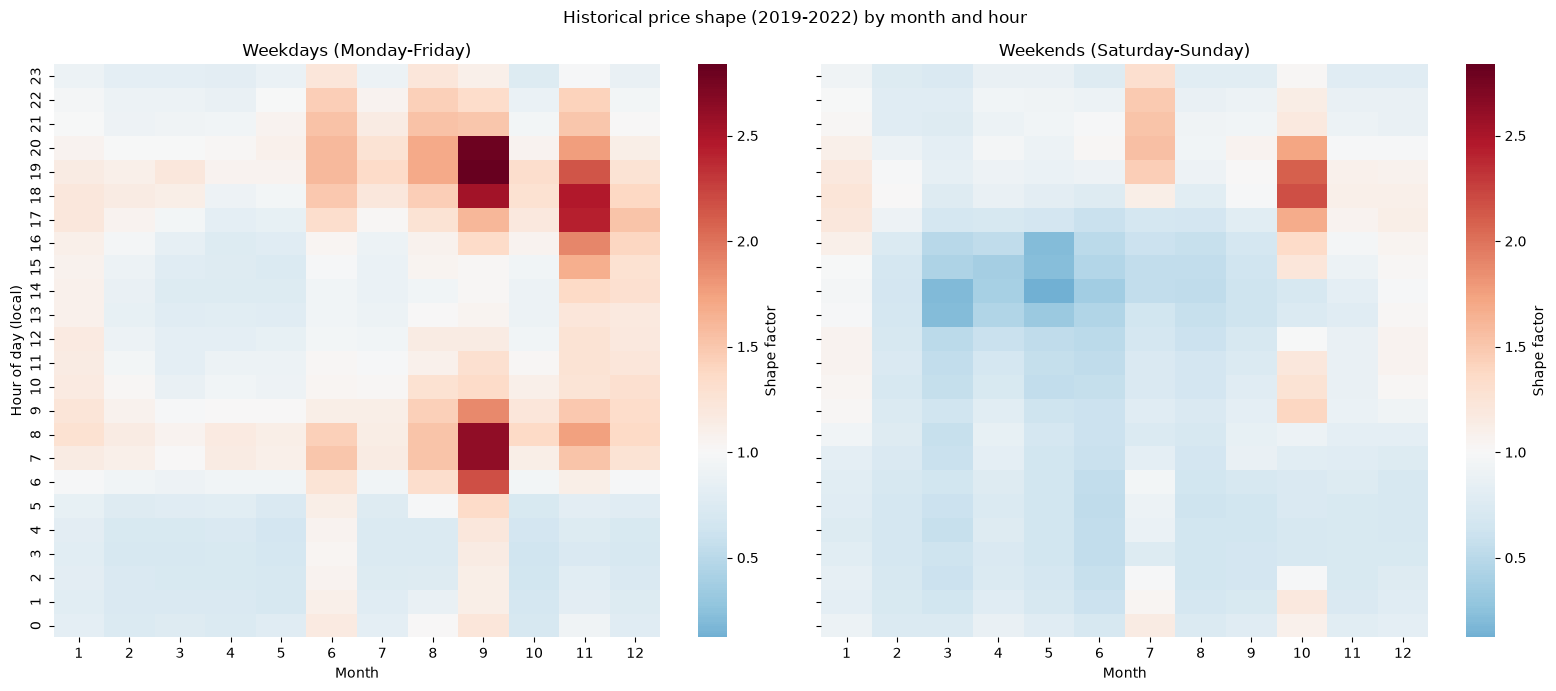

In [21]:
# the month-hour heatmap uses the historical shape factor
# I cover weekdays and weekends separately

# rows: average shape factor for every hour 
# columns: average shape factor for every month
weekday_map = shape[shape["weekday"] < 5].pivot_table(index="hour", columns="month", values="historical_shape_factor", aggfunc="mean")
weekend_map = shape[shape["weekday"] >= 5].pivot_table(index="hour", columns="month", values="historical_shape_factor", aggfunc="mean")

# same colour scale in both panels, so equal colours mean equal values
scale_min = min(weekday_map.min().min(), weekend_map.min().min())
scale_max = max(weekday_map.max().max(), weekend_map.max().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
# red = above 1 = more expensive than average
# blue = below 1 = cheaper than average
# white = 1 = average
sns.heatmap(weekday_map, ax=axes[0], cmap="RdBu_r", center=1, vmin=scale_min, vmax=scale_max, cbar_kws={"label": "Shape factor"})
sns.heatmap(weekend_map, ax=axes[1], cmap="RdBu_r", center=1, vmin=scale_min, vmax=scale_max, cbar_kws={"label": "Shape factor"})
axes[0].set_title("Weekdays (Monday-Friday)")
axes[1].set_title("Weekends (Saturday-Sunday)")
axes[0].set_xlabel("Month")
axes[1].set_xlabel("Month")
axes[0].set_ylabel("Hour of day (local)")
axes[1].set_ylabel("")
# put "hour 0" at the bottom
axes[0].invert_yaxis()
plt.suptitle("Historical price shape (2019-2022) by month and hour")
plt.tight_layout()
# save figure for report
plt.savefig("e3_heatmap.pdf", bbox_inches="tight")
plt.show()

### 3.2 Average shape factor per month with peak vs off-peak and weekday vs weekend

In [22]:
# average shape factor per month
# all hours, peak vs cff-peak, weekday vs weekend

factor = "historical_shape_factor"
summary = pd.DataFrame()
summary["all_hours"] = shape.groupby("month")[factor].mean()
summary["peak"] = shape[shape["is_peak"] == 1].groupby("month")[factor].mean()
summary["off_peak"] = shape[shape["is_peak"] == 0].groupby("month")[factor].mean()
summary["weekday"] = shape[shape["weekday"] < 5].groupby("month")[factor].mean()
summary["weekend"] = shape[shape["weekday"] >= 5].groupby("month")[factor].mean()

summary.loc["Year"] = [shape[factor].mean(),
                       shape.loc[shape["is_peak"] == 1, factor].mean(),
                       shape.loc[shape["is_peak"] == 0, factor].mean(),
                       shape.loc[shape["weekday"] < 5, factor].mean(),
                       shape.loc[shape["weekday"] >= 5, factor].mean()]
print(summary.round(2))

# Show columns instead of dates because the shape has one value per month, hour and weekday/weekend
# all quarter-hours with the lowest and the highest factor
lowest = shape[shape[factor] == shape[factor].min()]
highest = shape[shape[factor] == shape[factor].max()]

# Printing the value, how many days it occurs on and which month, hour and weekday (Monday = 0)
# I use drop_duplicates() to avoid printing the same values since the shape factor is the same for all quarter-hours in the same hour
print("\nLowest factor:", round(shape[factor].min(), 2), "on", lowest["timestamp_local"].dt.date.nunique(), "days")
print(lowest[["month", "hour", "weekday"]].drop_duplicates())
print("\nHighest factor:", round(shape[factor].max(), 2), "on", highest["timestamp_local"].dt.date.nunique(), "days")
print(highest[["month", "hour", "weekday"]].drop_duplicates())

       all_hours  peak  off_peak  weekday  weekend
month                                             
1           1.02  1.16      0.94     1.04     0.97
2           0.87  1.00      0.80     0.92     0.75
3           0.79  0.92      0.72     0.87     0.61
4           0.83  0.89      0.80     0.87     0.74
5           0.81  0.89      0.77     0.88     0.64
6           1.02  1.16      0.95     1.21     0.63
7           0.97  1.03      0.93     0.98     0.94
8           1.06  1.25      0.95     1.20     0.70
9           1.36  1.65      1.20     1.60     0.78
10          1.01  1.11      0.95     0.96     1.15
11          1.23  1.69      0.98     1.39     0.85
12          1.04  1.31      0.89     1.10     0.90
Year        1.00  1.17      0.91     1.08     0.80

Lowest factor: 0.12 on 8 days
       month  hour  weekday
11956      5    14        5
12052      5    14        6

Highest factor: 2.84 on 21 days
       month  hour  weekday
23592      9    19        0
23688      9    19        1
237

### 3.3 Interpretation

**What values above and below mean:**

The shape factor compares an hour with the average hour of the year. EX: a factor of 1.2 means that hour has historically been 20 % more expensive than average and 0.8 means 20 % cheaper. This isis relative so it says nothing about the price level in EUR/MWh.

Hours and seasons with high and low factors:
- Lowest factor: 0.12 at 14:00 on weekends in May (likely caused by solar power)
- Maximum factor:  2.84 at 19:00 on weekdays in September (likely caused by 2022 energy crisis being included in the dataset)

**Relationship between the shape and the Peak definition:**

- On average peak hours have a factor of 1.17 and off-peak hours 0.91 --> the peak window mostly covers the expensive hours. 
- The fit changes with the season. 
- Spring: the difference is small. EX: April with Peak 0.89 vs Off-Peak 0.80. Hypothesis: cheaper solar hours at midday
- Summer: evenings are expensive also after 20:00 outside the peak window
- November: the difference is large --> Peak 1.69 vs Off-Peak 0.98


Peak is above off-peak in every month of the historical shape 
- Exhibit 2: future price peak below base in Q2 and Q3 --> shape does not fully explain the futures prices. 
- It looks like the market on 29 September 2023 expected cheaper midday hours in 2024 than in 2019–2022 --> sign that the historical shape may be outdated

**Differences between weekdays and weekends:**

Weekdays have an average factor of 1.08 and weekends 0.80. Weekends are flatter and have a deeper dip in the middle of the day in spring and summer. October is an exception with higher weekend factors (1.15 vs 0.96). This can be caused by some extreme saturdays and sundays in the data set. 

### 3.4 Conclusion: what the historical shape adds to the futures quotes

A futures product only gives 1 average price for a whole block. This says nothing about which hours inside the block are expensive or cheap. 

If I multiply the block price with the shape factor and rescale so that its average inside the block is 1 I get a price for every hour. This adds the missing information about how prices vary between hours of the day, weekdays vs veekends and seasons. This makes it possible to value every hour in 2024.

The average of this hourly curve is still the futures price but expensive hours get a higher price and cheap hours a lower one. I do this separately for peak and off peak hours so the base and peak price is kept. I will look more into this in stage 2 with builidng the HPFC.

- Future gives the levels
- Shape gives the pattern inside the blocks

## Exhibit 4

In [23]:
# Combine day-ahead and reBAP (imbalance) prices into one table, 
# so both prices for the same quarter-hour are on the same row (joined on timestamp_utc)
realised_prices = day_ahead.merge(imbalance[["timestamp_utc", "imbalance_price_eur_mwh"]], on="timestamp_utc")
# shorter column names to make the table easier to read and use in charts
realised_prices = realised_prices.rename(columns={"day_ahead_price_eur_mwh": "day_ahead", "imbalance_price_eur_mwh": "rebap"})
realised_prices.head()

,timestamp_utc,timestamp_local,day_ahead,rebap
0,2023-12-31 23:00:00+00:00,2024-01-01 00:00:00+01:00,0.10,75.15
1,2023-12-31 23:15:00+00:00,2024-01-01 00:15:00+01:00,0.10,78.53
2,2023-12-31 23:30:00+00:00,2024-01-01 00:30:00+01:00,0.10,83.17
3,2023-12-31 23:45:00+00:00,2024-01-01 00:45:00+01:00,0.10,75.15
4,2024-01-01 00:00:00+00:00,2024-01-01 01:00:00+01:00,0.01,79.13


### 4.1 Time series for day-ahead and reBAP

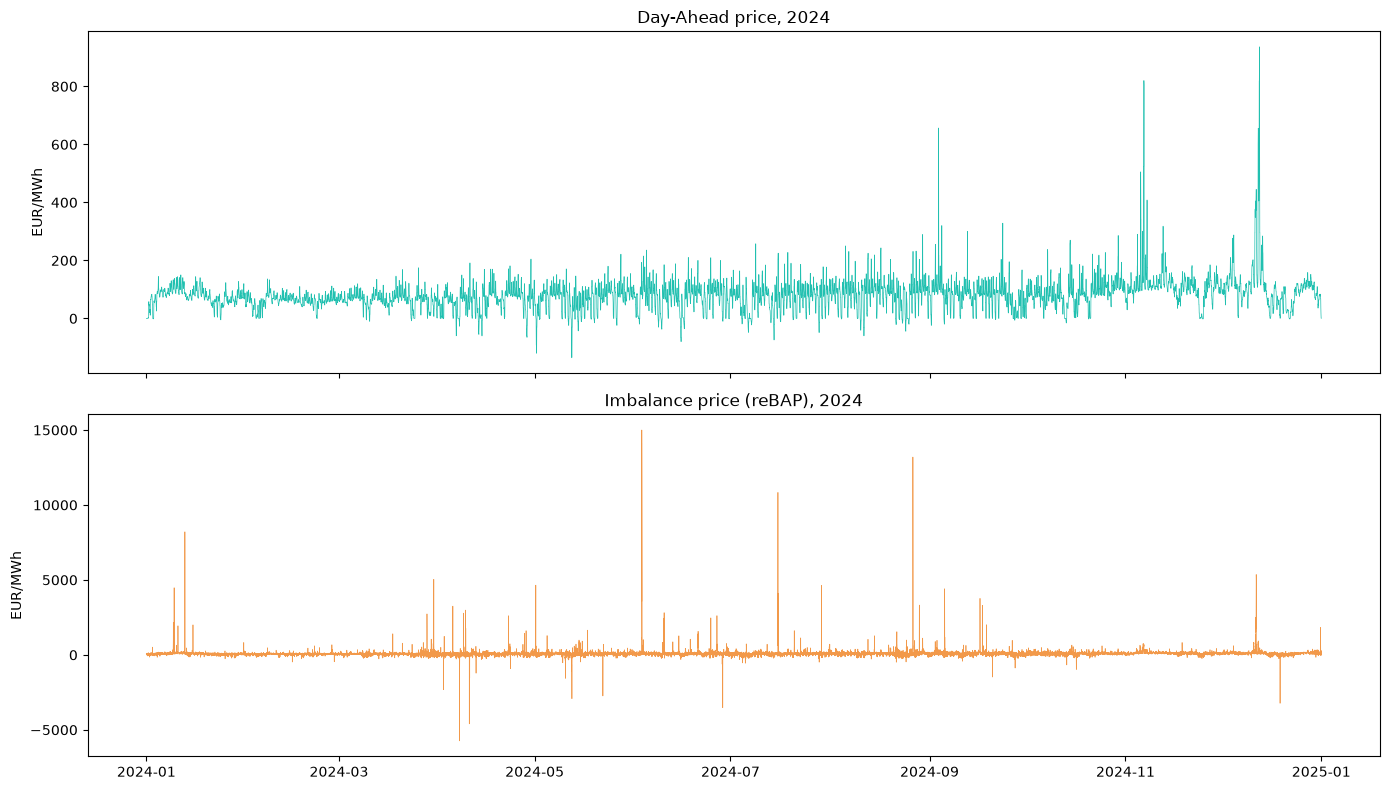

In [24]:
# time series
# two panels sharing the time axis, each with its own price scale
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(realised_prices["timestamp_local"], realised_prices["day_ahead"], color="#21C0B0", linewidth=0.5)
axes[0].set_title("Day-Ahead price, 2024")
axes[0].set_ylabel("EUR/MWh")
axes[1].plot(realised_prices["timestamp_local"], realised_prices["rebap"], color="#F2994A", linewidth=0.5)
axes[1].set_title("Imbalance price (reBAP), 2024")
axes[1].set_ylabel("EUR/MWh")
plt.tight_layout()
# save the figure as pdf for the report
plt.savefig("e4_timeseries.pdf", bbox_inches="tight")
plt.show()

Day-Ahead mostly lies between 0 and 200 EUR/MWh. The biggest spikes are in November and December and negative prices mainly in spring and summer. 

reBAP moves around the same level but has much larger spikes in both directions throughout the whole year. The two panels have different y-axes, because reBAP varies more than day-ahead.

### 4.2 Distribution: is reBAP more variable than day-ahead?

      day_ahead     rebap
0.0     -135.45  -5734.46
0.01     -19.99   -175.64
0.05      -0.01    -96.71
0.25      55.56     17.16
0.5       79.59     89.96
0.75     101.34    135.62
0.95     143.25    220.53
0.99     224.92    447.85
1.0      936.28  14999.99
std       52.72    282.66


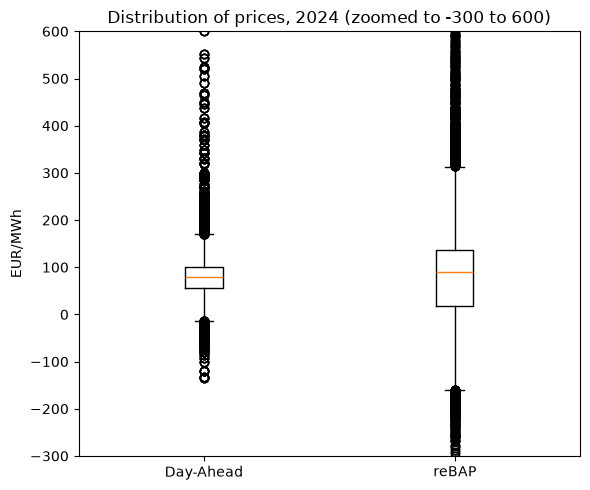

In [25]:
# Distribution with quantile table, standard deviation and box plot

# selected quantiles of both prices (0 = minimum, 1 = maximum)
distribution = realised_prices[["day_ahead", "rebap"]].quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1])
# last row: standard deviation over the whole year
distribution.loc["std"] = realised_prices[["day_ahead", "rebap"]].std()
print(distribution.round(2))

# box plot zoomed in on -300 to 600 EUR/MWh to make the boxes visible
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([realised_prices["day_ahead"], realised_prices["rebap"]])
ax.set_xticks([1, 2])
ax.set_xticklabels(["Day-Ahead", "reBAP"])
ax.set_ylim(-300, 600)
ax.set_title("Distribution of prices, 2024 (zoomed to -300 to 600)")
ax.set_ylabel("EUR/MWh")
plt.tight_layout()
# save the figure as pdf for the report
plt.savefig("e4_distribution.pdf", bbox_inches="tight")
plt.show()

Boxp-plot: reBAP is more variable than day-ahead and spreads out more with wider box and tails. The two prices have a similar typical level. 

Table: standard deviation is about 5 times higher. 

So a MWh bought or sold at the imbalance price is more uncertain than a MWh bought in the day-ahead market. 

### 4.3 Extreme positive and negative prices

In [26]:
for column in ["day_ahead", "rebap"]:
    lowest = realised_prices[column].idxmin()
    highest = realised_prices[column].idxmax()
    print(column + " lowest: ", realised_prices.loc[lowest, column], "EUR/MWh at", realised_prices.loc[lowest, "timestamp_local"])
    print(column + " highest:", realised_prices.loc[highest, column], "EUR/MWh at", realised_prices.loc[highest, "timestamp_local"])

# how often prices are negative
# I divide the 4 quarter hours by 4 to get hours since day-ahead is an hourly price
print("\nHours with a negative Day-Ahead price:", int((realised_prices["day_ahead"] < 0).sum() / 4))
print("Quarter-hours with a negative reBAP:", (realised_prices["rebap"] < 0).sum())
print("Quarter-hours with reBAP above 1,000 EUR/MWh:", (realised_prices["rebap"] > 1000).sum())

day_ahead lowest:  -135.45 EUR/MWh at 2024-05-12 13:00:00+02:00
day_ahead highest: 936.28 EUR/MWh at 2024-12-12 17:00:00+01:00
rebap lowest:  -5734.46 EUR/MWh at 2024-04-07 14:15:00+02:00
rebap highest: 14999.99 EUR/MWh at 2024-06-03 09:00:00+02:00

Hours with a negative Day-Ahead price: 457
Quarter-hours with a negative reBAP: 6962
Quarter-hours with reBAP above 1,000 EUR/MWh: 115


The maximum reBAP is almost exactly 15 000, which looks like a price limit.

### 4.4 Periods of elavated volatility

       day_ahead  rebap
month                  
1           29.2  199.4
2           21.3   66.5
3           26.3  161.0
4           41.4  239.0
5           44.9  200.9
6           47.7  644.2
7           46.2  266.5
8           49.6  380.3
9           54.1  198.1
10          42.9   93.6
11          64.9   93.2
12          92.0  315.2


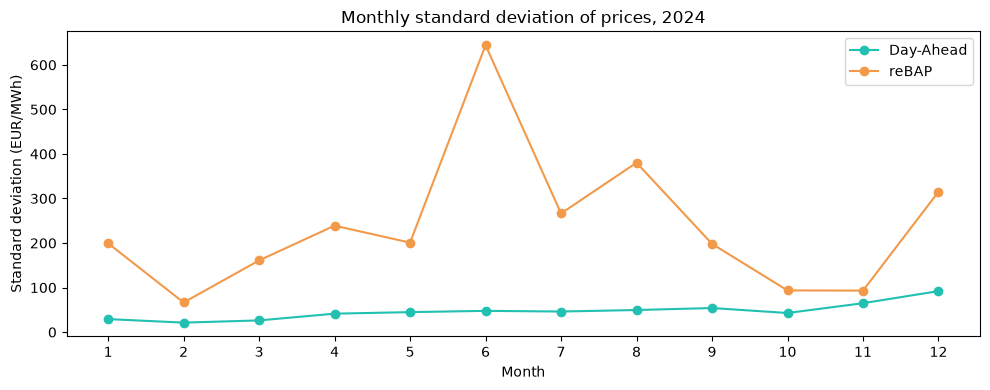

In [27]:
# using the standard deviation to identify periods of elevated volatility
realised_prices["month"] = realised_prices["timestamp_local"].dt.month
monthly_std = realised_prices.groupby("month")[["day_ahead", "rebap"]].std()
print(monthly_std.round(1))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_std.index, monthly_std["day_ahead"], color="#21C0B0", marker="o", label="Day-Ahead")
ax.plot(monthly_std.index, monthly_std["rebap"], color="#F2994A", marker="o", label="reBAP")
ax.set_xticks(range(1, 13))
ax.set_title("Monthly standard deviation of prices, 2024")
ax.set_xlabel("Month")
ax.set_ylabel("Standard deviation (EUR/MWh)")
ax.legend()
plt.tight_layout()
# save figur for report
plt.savefig("e4_monthly_std.pdf", bbox_inches="tight")
plt.show()

Day-Ahead volatility grows through the year and is highest in November and December.

reBAP does not follow a clear seasonal pattern. Its most volatile months (June) looks like its driven by single extreme events rather than by the season.

### 4.5 One market episode for the main project

In [28]:
# the 5 days with the highest average day-ahead price

realised_prices["date"] = realised_prices["timestamp_local"].dt.date
daily = realised_prices.groupby("date")[["day_ahead", "rebap"]].agg(["mean", "max"])
print(daily.sort_values(("day_ahead", "mean"), ascending=False).head(5).round(1))

           day_ahead         rebap        
                mean    max   mean     max
date                                      
2024-12-12     395.3  936.3  233.1   931.4
2024-12-11     266.5  445.1  994.8  5359.2
2024-11-06     231.1  820.1  324.6   743.8
2024-12-04     182.5  287.8  161.3   606.0
2024-12-13     178.5  284.2  146.6   352.2


I choose 11–12 December 2024 for further investigation because it is interesting to see a period where both day-ahead and imbalance price were extreme over more than one day. This will be elaborated in stage 7.

## Close the briefing

### 1) Which information was available on 29 September 2023, and which became known only during delivery?

Known when the hedge was designed:

- the customer table with number of customers and annual consumption per customer
- the standard load profiles which give the expected shape of consumption
- the futures prices and market_activity from 29 September 2023
- the historical shape factors built from 2019–2022 day-ahead prices

Known during or after delivery:

- day-ahead prices are set the day before each delivery day
- the actual portfolio load is only known after the customers have used the electricity
- the reBAP imbalance prices are only known after delivery

So to build the hedge I only use forecast and future prices. Realised prices and consumption is used afterward to evaluate. 

### 2) What data checks did you perform before trusting the analysis?

Before using the data I checked every file (see The data on my desk):
- all time series have 35 136 rows (366 days × 96 quarter-hours) and no missing values and duplicate timestamps
- the timestamps were text so I converted them to datetime. UTC is used to join the files and Berlin time to read daily and weekly patterns.
- the summer/winter time-change have 92 (31 March) and 100 (27 October) quarter-hours
- each SLP sums to 1 000 000 kWh confirming the data dictionary
- the shape factor averages 1 and all values are positive
- the day-ahead price is the same in all four quarter-hours of each hour
- is_peak matches the Peak definition (Monday–Friday 08:00–20:00 local time)
- the futures file has one Base and one Peak price for each of the 17 delivery periods from same quote date and no duplicate products
- the actual load groups add up to the total

During the exhibits I also checked:
- the scaled portfolio reconciles with the customer table (43 000 MWh, Exhibit 1)
- each hedge option covers 2024 with no gaps and no overlap (Exhibit 2) 
- the date and time of 5 extreme prices (Exhibit 4)
- Negative and extreme prices were kept because I assume they are real market outcomes and not data errors.

### 3) If the strategy were executed for a real retail portfolio, what important information or market features would still be missing?

*Identify at least three assumptions or simplifications and explain how each could affect the analysis.*

**The forecast is a fixed standard profile:** 

The load is the SLP scaled to a fixed customer table. It is simplified and does not include data on weather, holidays or change in the number of customers. The actual load differs from the forecast (43 138 vs 43 000 MWh) and is settled at reBAP. reBAP is by far the most volatile price. The real volume risk can therefore be larger than the analysis shows. F.ex. in a cold period when both demand and prices are high.

**The futures market is simplified:** 

The products does not include shorter products such as week or weekend. market_activity is a synthetic indicator and there are no bid–ask spreads, transaction costs, whole-contract lots or margin payments. A real hedge would therefore cost more and need cash for margin calls and the set of tradable products could be different.

**The historical shape may not fit 2024:** 

It is based on only four years (including the 2022 energy crisis). The shape has one value per month, weekday and hour, so public holidays are treated like normal days. More solar power since then has changed the hourly pattern (Dennis' Lecture). The hourly values built from this shape could put too much or too little value on some hours, which can affect how the hedge is sized.

**The hedge only uses Base and Peak futures:**

Futures fix the price for a fixed volume, so they cannot protect against the customers using more or less than forecast or against rare extreme prices. Oum (2006) (given litterature) show that options can hedge this kind of volume risk. The model also assumes the whole forecast is bought day-ahead and any deviation is settled at reBAP, with no intraday trading. The remaining volume and tail risk in the analysis therefore comes from the choice of instruments not only from the forecast.


# Case study

## Section 2: Strategies and futures products

### Selected products per strategy

In [29]:
# The three strategies and the futures products they use
# see market activity criterion and the product selection in exhibit 2

strategies = ["UNHEDGED", "COARSE_CAL", "GRANULAR"]
strategy_products = [[],
                     ["CAL"],
                     ["M01", "M02", "M03", "Q2", "Q3", "Q4"]]

# the Base and Peak prices of the selected products 
# used to build the HPFC and the hedge
selected = futures[futures["delivery_period"].isin(["CAL", "M01", "M02", "M03", "Q2", "Q3", "Q4"])]
print()
print(selected[["delivery_period", "load_type", "price_eur_mwh", "market_activity"]])


   delivery_period load_type  price_eur_mwh  market_activity
0              CAL      BASE          77.26             5000
1              CAL      PEAK          86.60             1400
4               Q2      BASE          66.23             2200
5               Q2      PEAK          64.76              616
6               Q3      BASE          74.74             1600
7               Q3      PEAK          69.07              448
8               Q4      BASE         101.39             1400
9               Q4      PEAK         134.42              392
10             M01      BASE          75.32              900
11             M01      PEAK          88.68              252
12             M02      BASE          60.09              800
13             M02      PEAK          70.59              224
14             M03      BASE          63.45              650
15             M03      PEAK          72.79              182


### Proof: each hedge covers every quarter-hour of 2024 exactly once

In [30]:
# grid = main table for the case study with one row per quarter-hour of 2024
# proof that each hedge covers every quarter-hour of 2024 exactly once

grid = slp[["timestamp_utc", "timestamp_local"]].copy()

for i in range(1, len(strategies)):
    # how many products deliver in each quarter-hour and which product it is
    count = pd.Series(0, index=grid.index)
    block = pd.Series("", index=grid.index)
    for product in strategy_products[i]:
        # delivery window of the product
        product_start = pd.Timestamp(base.loc[product, "delivery_start"], tz="Europe/Berlin")
        product_end = pd.Timestamp(base.loc[product, "delivery_end_exclusive"], tz="Europe/Berlin")
        in_product = (grid["timestamp_local"] >= product_start) & (grid["timestamp_local"] < product_end)
        count = count + in_product.astype(int)
        block[in_product] = product
    # save which product covers each quarter-hour
    # I need it later for the HPFC and the hedge
    grid["block_" + strategies[i].lower()] = block
    print(strategies[i] + ": quarter-hours not covered = " + str((count == 0).sum())
          + ", covered more than once = " + str((count > 1).sum()))

# number of quarter-hours in each GRANULAR block
print()
print(grid["block_granular"].value_counts().reindex(["M01", "M02", "M03", "Q2", "Q3", "Q4"]))

COARSE_CAL: quarter-hours not covered = 0, covered more than once = 0
GRANULAR: quarter-hours not covered = 0, covered more than once = 0

block_granular
M01    2976
M02    2784
M03    2972
Q2     8736
Q3     8832
Q4     8836
Name: count, dtype: int64


I use the market_activity criterion from Exhibit 2 (≥ 100), so only usable products are included. 
- UNHEDGED uses no futures. 
- COARSE_CAL uses CAL Base and Peak. 
- GRANULAR uses the finest non-overlapping usable set: M01, M02, M03 followed by Q2, Q3 and Q4 (Base and Peak). 

The check on the quarter-hour grid shows that both hedges cover all 35 136 quarter-hours of 2024 exactly once with no gaps and overlap. March has 4 fewer quarter-hours and Q4 has 4 more because of the clock changes.

## Stage 1: Forecast the customer portfolio

### 1.1 Forecast load per quarter hour

In [31]:
# Add the forecast load to grid
# grid was made from slp. rows are already in the same order
load_columns = ["hb_load_mwh", "gb_load_mwh", "lb_load_mwh", "total_load_mwh"]
for i in range(len(load_columns)):
    grid[load_columns[i]] = slp[load_columns[i]]

# pandas copies a column row by row
# first I check that every row is the same quarter-hour in grid and shape
print("Same timestamps in grid and shape:", (grid["timestamp_utc"] == shape["timestamp_utc"]).all())
grid["is_peak"] = shape["is_peak"]

# check: the same annual energy as in the reconciliation in Exhibit 1.2
print("Annual forecast energy (MWh):")
print(grid[load_columns].sum().round(2))

Same timestamps in grid and shape: True
Annual forecast energy (MWh):
hb_load_mwh       35000.0
gb_load_mwh        6000.0
lb_load_mwh        2000.0
total_load_mwh    43000.0
dtype: float64


The forecast load L_t was built in Exhibit 1.1 and reconciles with the customer table (43 000 MWh, Exhibit 1.2). Add it to grid so the load, prices and hedge will later be on the same quarter-hour row.

### 1.2 Quarterly-hour energy (MWh) vs. average power (MW)

In [32]:
# Quarter-hourly energy (MWh) vs average power (MW)

# 2024 has 35,136 quarter-hours = 8,784 hours
hours_in_2024 = len(grid) / 4
print("Hours in 2024:", hours_in_2024)
print("Annual energy:", round(grid["total_load_mwh"].sum(), 2), "MWh")
print("Average power:", round(grid["total_load_mwh"].sum() / hours_in_2024, 2), "MW")

# MWh in one quarter-hour divided by 0.25 hours gives the average power (MW) in that quarter-hour
mwh_vs_mw = pd.DataFrame(index=["lowest quarter-hour", "average quarter-hour", "highest quarter-hour"])
mwh_vs_mw["energy_mwh_per_quarter_hour"] = [grid["total_load_mwh"].min(), grid["total_load_mwh"].mean(), grid["total_load_mwh"].max()]
mwh_vs_mw["average_power_mw"] = mwh_vs_mw["energy_mwh_per_quarter_hour"] / 0.25
print(mwh_vs_mw.round(2))

Hours in 2024: 8784.0
Annual energy: 43000.0 MWh
Average power: 4.9 MW
                      energy_mwh_per_quarter_hour  average_power_mw
lowest quarter-hour                          0.42              1.68
average quarter-hour                         1.22              4.90
highest quarter-hour                         2.60             10.40


The load data is energy: 

MWh used in one quarter-hour. Futures are traded as power in MW, meaning a constant rate over time. 

To go from MWh per quarter-hour to MW: I divide by 0.25 hours (× 4). 

Over the year the portfolio uses 43 000 MWh, which is 4.90 MW on average over 8 784 hours. In single quarter-hours the load goes from 0.42 MWh (1.68 MW) to 2.60 MWh (10.40 MW). This matters because a 1 MW futures position delivers 0.25 MWh in each quarter-hour, so the hedge in Stage 3 must be converted to MWh before it can be compared with the load.

### 1.3 Seasonal shape and peak vs. off-peak load

         HB    GB    LB  Total  Total_peak  Total_off_peak  peak_vs_off_peak
month                                                                       
1      4.77  0.71  0.25   5.73        7.17            4.89              1.47
2      4.63  0.72  0.25   5.60        6.99            4.81              1.45
3      4.37  0.68  0.24   5.29        6.59            4.62              1.42
4      4.02  0.68  0.23   4.93        6.07            4.27              1.42
5      3.66  0.65  0.22   4.53        5.58            3.90              1.43
6      3.41  0.66  0.21   4.27        5.27            3.77              1.40
7      3.26  0.67  0.21   4.14        5.12            3.57              1.44
8      3.35  0.67  0.21   4.23        5.21            3.68              1.41
9      3.55  0.67  0.22   4.44        5.49            3.88              1.41
10     3.91  0.69  0.23   4.82        5.94            4.16              1.43
11     4.21  0.72  0.25   5.18        6.48            4.47              1.45

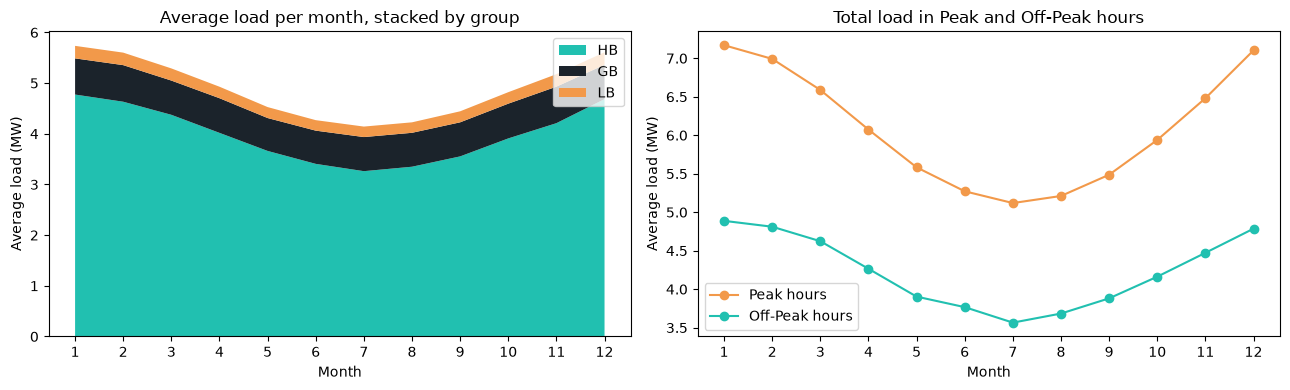

In [33]:
# Seasonal shape
# average load per month and Peak vs Off-Peak

grid["month"] = grid["timestamp_local"].dt.month
# average load per month, times 4 to go from MWh per quarter-hour to MW
monthly_mw = grid.groupby("month")[load_columns].mean() * 4
monthly_mw.columns = ["HB", "GB", "LB", "Total"]
# average total load in peak and in off-peak hours per month (MW)
monthly_mw["Total_peak"] = grid[grid["is_peak"] == 1].groupby("month")["total_load_mwh"].mean() * 4
monthly_mw["Total_off_peak"] = grid[grid["is_peak"] == 0].groupby("month")["total_load_mwh"].mean() * 4
# peak load vs off peak load per month
monthly_mw["peak_vs_off_peak"] = monthly_mw["Total_peak"] / monthly_mw["Total_off_peak"]
print(monthly_mw.round(2))

# how much of the energy is used in Peak hours, compared with how much of the time is Peak
peak_share_time = grid["is_peak"].mean() * 100
peak_share_energy = grid.loc[grid["is_peak"] == 1, "total_load_mwh"].sum() / grid["total_load_mwh"].sum() * 100
print("\nShare of quarter-hours that are Peak:", round(peak_share_time, 1), "%")
print("Share of annual energy used in Peak hours:", round(peak_share_energy, 1), "%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# left
# stacked average load per month by customer group
axes[0].stackplot(monthly_mw.index, monthly_mw["HB"], monthly_mw["GB"], monthly_mw["LB"], labels=names, colors=colors)
axes[0].set_title("Average load per month, stacked by group")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average load (MW)")
axes[0].set_xticks(range(1, 13))
axes[0].legend(loc="upper right")
# right 
# total load in Peak and Off-Peak hours per month
axes[1].plot(monthly_mw.index, monthly_mw["Total_peak"], color="#F2994A", marker="o", label="Peak hours")
axes[1].plot(monthly_mw.index, monthly_mw["Total_off_peak"], color="#21C0B0", marker="o", label="Off-Peak hours")
axes[1].set_title("Total load in Peak and Off-Peak hours")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average load (MW)")
axes[1].set_xticks(range(1, 13))
axes[1].legend()
plt.tight_layout()
plt.savefig("s1_seasonal.pdf", bbox_inches="tight")   # save the figure as PDF for the report
plt.show()

### 1.4 How the customer mix affects the load shape and the use of base and peak futures

**Daily shape (Exhibit 1):**

HB is 81 % of the energy, so the total load follows the household shape: low at night, high around midday and highest in the evening (19:00). GB adds load in working hours on weekdays.

**Seasonal shape:**

The load is higher in winter than in summer (5.73 MW in January vs 4.14 MW in July). The change comes almost only from HB, while GB and LB are nearly flat through the year.

**Use of Base futures:**

The load never goes below 1.68 MW and Off-Peak load is between 3.57 and 4.89 MW, so a large part of the load is always there and fits a Base product.


**Use of Peak futures:**

Peak hours are 35.8 % of the time but use 44.5 % of the energy and Peak load is about 1.4 times Off-Peak load in every month. A Peak product can therefore add volume on top of Base in these hours.

**Limits:** 

The load is still high after 20:00 on weekdays (Exhibit 1.3) and on weekends which Peak does not cover. The winter–summer difference cannot be followed by one flat annual product. This is why a more granular hedge with months and quarters can follow the seasonal shape better than CAL. How big the positions should be is decided in Stage 3.

## Stage 2: Construct the HPFC

### 2.1 Implied off-peak price per granular period

In [34]:
# Implied off-peak price for each GRANULAR period: 
# P_off = (P_base * N_all - P_peak * N_peak) / N_off

granular = ["M01", "M02", "M03", "Q2", "Q3", "Q4"]
calibration = pd.DataFrame(index=granular)
# quoted base and peak prices from futures_prices in Exhibit 2.1
calibration["P_base"] = futures_prices.loc[granular, "BASE"]
calibration["P_peak"] = futures_prices.loc[granular, "PEAK"]
# number of all peak and off-peak quarter-hours in each period
calibration["N_all"] = grid.groupby("block_granular").size()
calibration["N_peak"] = grid[grid["is_peak"] == 1].groupby("block_granular").size()
calibration["N_off"] = calibration["N_all"] - calibration["N_peak"]
# implied off-peak price
calibration["P_off"] = (calibration["P_base"] * calibration["N_all"] - calibration["P_peak"] * calibration["N_peak"]) / calibration["N_off"]
print(calibration.round(2))

     P_base  P_peak  N_all  N_peak  N_off  P_off
M01   75.32   88.68   2976    1104   1872  67.44
M02   60.09   70.59   2784    1008   1776  54.13
M03   63.45   72.79   2972    1008   1964  58.66
Q2    66.23   64.76   8736    3120   5616  67.05
Q3    74.74   69.07   8832    3168   5664  77.91
Q4   101.39  134.42   8836    3168   5668  82.93


### 2.2 Apply the historical price shape

HPFC from 9.75 to 244.48 EUR/MWh


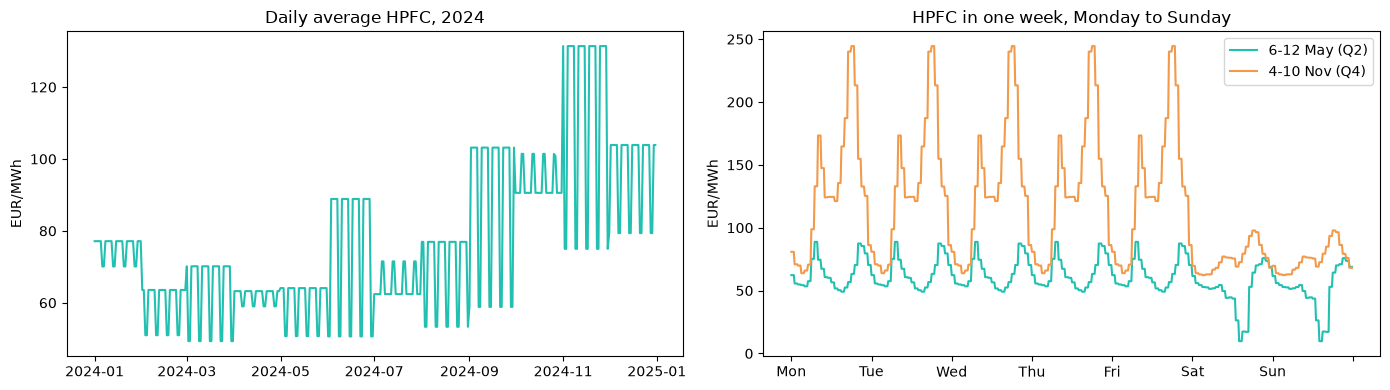

In [35]:
# HPFC_t = P_slice * s_t / mean_slice(s)
# done separately for peak and off-peak inside each period

grid["shape_factor"] = shape["historical_shape_factor"]
grid["hpfc"] = 0.0
for period in granular:
    for peak_flag in [1, 0]:
        # the quarter-hours in this slice one period and peak or off-peak
        in_slice = (grid["block_granular"] == period) & (grid["is_peak"] == peak_flag)
        # the flat price of the slice is the quoted peak price or the implied off-peak price
        if peak_flag == 1:
            slice_price = calibration.loc[period, "P_peak"]
        else:
            slice_price = calibration.loc[period, "P_off"]
        # rescale the shape so to mean in the slide = 1
        # then multiply with the slice price
        slice_mean = grid.loc[in_slice, "shape_factor"].mean()
        grid.loc[in_slice, "hpfc"] = slice_price * grid.loc[in_slice, "shape_factor"] / slice_mean

print("HPFC from", round(grid["hpfc"].min(), 2), "to", round(grid["hpfc"].max(), 2), "EUR/MWh")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# left
# daily average HPFC over the year
daily_hpfc = grid.groupby(grid["timestamp_local"].dt.date)["hpfc"].mean()
axes[0].plot(daily_hpfc.index, daily_hpfc.values, color="#21C0B0")
axes[0].set_title("Daily average HPFC, 2024")
axes[0].set_ylabel("EUR/MWh")
# right
# one week in may and one week in november quarter-hour by quarter-hour
may_week = grid[(grid["timestamp_local"] >= pd.Timestamp("2024-05-06", tz="Europe/Berlin")) & (grid["timestamp_local"] < pd.Timestamp("2024-05-13", tz="Europe/Berlin"))]
nov_week = grid[(grid["timestamp_local"] >= pd.Timestamp("2024-11-04", tz="Europe/Berlin")) & (grid["timestamp_local"] < pd.Timestamp("2024-11-11", tz="Europe/Berlin"))]
axes[1].plot(range(len(may_week)), may_week["hpfc"], color="#21C0B0", label="6-12 May (Q2)")
axes[1].plot(range(len(nov_week)), nov_week["hpfc"], color="#F2994A", label="4-10 Nov (Q4)")
# one tick per day (96 quarter-hours)
axes[1].set_xticks(range(0, 7 * 96 + 1, 96))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun", ""])
axes[1].set_title("HPFC in one week, Monday to Sunday")
axes[1].set_ylabel("EUR/MWh")
axes[1].legend()
plt.tight_layout()
# save figures for report
plt.savefig("s2_hpfc.pdf", bbox_inches="tight")
plt.show()

Inside each period I rescale the historical shape factor separately for peak and off-peak hours so its average is 1 and multiply it with the peak price or the implied off-peak price. 

The shape then decides which hours are expensive or cheap (in relative), while the futures decide the level. 

The left chart shows steps between months and inside a quarter, because the shape also contains a monthly level. 

The right chart shows the hourly pattern from Exhibit 3. With sharp weekday evening peaks in November and a flatter week with cheap midday weekend hours in May.

### 2.3 Reconcile the curve with the futures quotes

In [36]:
# Reconciliation 1
# in every period the mean HPFC must equal the quoted prices

reconciliation_hpfc = pd.DataFrame(index=granular)
reconciliation_hpfc["P_base"] = calibration["P_base"]
reconciliation_hpfc["mean_hpfc_all"] = grid.groupby("block_granular")["hpfc"].mean()
reconciliation_hpfc["P_peak"] = calibration["P_peak"]
reconciliation_hpfc["mean_hpfc_peak"] = grid[grid["is_peak"] == 1].groupby("block_granular")["hpfc"].mean()
reconciliation_hpfc["diff_base"] = reconciliation_hpfc["mean_hpfc_all"] - reconciliation_hpfc["P_base"]
reconciliation_hpfc["diff_peak"] = reconciliation_hpfc["mean_hpfc_peak"] - reconciliation_hpfc["P_peak"]
print(reconciliation_hpfc.round(4))

# Reconciliation 2
# independent check with usable products NOT used to build the HPFC (CAL and Q1)
check = pd.DataFrame(index=["CAL", "Q1"])
# Q1 = all quarter-hours before 1 April 2024
in_q1 = grid["timestamp_local"] < pd.Timestamp("2024-04-01", tz="Europe/Berlin")
check["quote_base"] = [futures_prices.loc["CAL", "BASE"], futures_prices.loc["Q1", "BASE"]]
check["hpfc_base"] = [grid["hpfc"].mean(), grid.loc[in_q1, "hpfc"].mean()]
check["quote_peak"] = [futures_prices.loc["CAL", "PEAK"], futures_prices.loc["Q1", "PEAK"]]
check["hpfc_peak"] = [grid.loc[grid["is_peak"] == 1, "hpfc"].mean(), grid.loc[in_q1 & (grid["is_peak"] == 1), "hpfc"].mean()]
check["diff_base"] = check["hpfc_base"] - check["quote_base"]
check["diff_peak"] = check["hpfc_peak"] - check["quote_peak"]
print()
print(check.round(4))

     P_base  mean_hpfc_all  P_peak  mean_hpfc_peak  diff_base  diff_peak
M01   75.32          75.32   88.68           88.68        0.0        0.0
M02   60.09          60.09   70.59           70.59       -0.0        0.0
M03   63.45          63.45   72.79           72.79       -0.0        0.0
Q2    66.23          66.23   64.76           64.76       -0.0       -0.0
Q3    74.74          74.74   69.07           69.07       -0.0       -0.0
Q4   101.39         101.39  134.42          134.42        0.0        0.0

     quote_base  hpfc_base  quote_peak  hpfc_peak  diff_base  diff_peak
CAL       77.26    77.2594        86.6    86.6044    -0.0006     0.0044
Q1        66.42    66.4242        77.7    77.7018     0.0042     0.0018


In every period the mean HPFC equals the quoted base and peak price, which is expected since the curve is built to do this. 

As an independent check I use the usable products that were not used to build the curve: CAL and Q1. The HPFC reproduces both within less than 0.01 EUR/MWh. The small difference comes from the quotes being rounded to two decimals, so the GRANULAR prices are consistent with the coarser CAL and Q1 prices.

### 2.4 Why the HPFC is usefor for valuation but not a forecast

The HPFC is useful for valuation because every hour gets a price that is consistent with prices that could actually be traded on 29 September 2023. 

This lets me value the customer load and the hedge hour by hour on the same curve (Stage 3). But it is not a forecast of the realised day-ahead prices. It uses only 12 futures prices and a fixed historical shape, so it cannot know about 2024 events such as weather, outages or the December price spike (Exhibit 4). It tells what an hour is worth today according to the market, not what the price will actually be (Dennis' lecture).

## Stage 3: Optimise the futures hedge

### 3.1 Hedge energy, value neutrality and shape mismatch

In [37]:
# Optimal Base and Peak position (MW) for one block
# H_t = 0.25 * (x_base + x_peak * is_peak)   
# hedge energy in MWh per quarter-hour

# constraint:
# sum(H_t * HPFC_t) = sum(L_t * HPFC_t) in the block   
# (value neutrality)

# objective:
# minimise sum((L_t - H_t)^2) in the block             
# (shape mismatch)

# bounds:
# x_base >= 0 and x_peak >= 0                          
# (no short positions)

def optimal_hedge(block_rows):
    # load: HPFC and Peak flag of the quarter-hours in this block
    load = block_rows["total_load_mwh"].values
    hpfc = block_rows["hpfc"].values
    peak = block_rows["is_peak"].values

    # hedge energy in every quarter-hour for a given position x = [x_base, x_peak]
    def hedge_energy(x):
        return 0.25 * (x[0] + x[1] * peak)

    # objective: sum of squared differences between load and hedge
    def shape_mismatch(x):
        return np.sum((load - hedge_energy(x)) ** 2)

    # constraint: hedge value minus load value under the HPFC must be 0
    def value_gap(x):
        return np.sum(hedge_energy(x) * hpfc) - np.sum(load * hpfc)

    # start with a flat base position equal to the average load (MW) and no peak
    start = [load.mean() * 4, 0]
    result = minimize(shape_mismatch, start, method="SLSQP",
                      constraints=[{"type": "eq", "fun": value_gap}],
                      bounds=[(0, None), (0, None)])
    return result.x[0], result.x[1], result.success

A Base position of x_base MW delivers 0.25 × x_base MWh in every quarter-hour of its block. A Peak position adds 0.25 × x_peak MWh in the Peak quarter-hours. 

In each block I choose x_base and x_peak so that the hedge has the same value as the forecast load under the HPFC (value neutrality). Among all positions with this value, I pick the one closest to the load shape (smallest sum of squared differences). 

The case required positions to be 0 or above. The retailer must deliver power to its customers, so selling futures would increase its risk instead of reducing it. COARSE_CAL has one block (the whole year) and GRANULAR has six (M01, M02, M03, Q2, Q3, Q4).

### 3.2 Optimal futures positions per strategy

In [38]:
# Solve every block of the two hedged strategies

positions = pd.DataFrame(columns=["strategy", "block", "x_base_mw", "x_peak_mw", "solved"])
# UNHEDGED has no futures, so its hedge energy is 0 in every quarter-hour
grid["hedge_unhedged_mwh"] = 0.0
grid["hedge_coarse_cal_mwh"] = 0.0
grid["hedge_granular_mwh"] = 0.0

for i in range(1, len(strategies)):
    block_column = "block_" + strategies[i].lower()
    hedge_column = "hedge_" + strategies[i].lower() + "_mwh"
    for product in strategy_products[i]:
        # optimise each block on its own with one value constraint per block
        in_block = grid[block_column] == product
        x_base, x_peak, solved = optimal_hedge(grid[in_block])
        # hedge energy (MWh) in every quarter-hour of the block
        grid.loc[in_block, hedge_column] = 0.25 * (x_base + x_peak * grid.loc[in_block, "is_peak"])
        positions.loc[len(positions)] = [strategies[i], product, x_base, x_peak, solved]

print(positions.round(2))

     strategy block  x_base_mw  x_peak_mw  solved
0  COARSE_CAL   CAL       4.39       1.88    True
1    GRANULAR   M01       5.04       2.33    True
2    GRANULAR   M02       4.93       2.22    True
3    GRANULAR   M03       4.65       1.97    True
4    GRANULAR    Q2       4.00       1.68    True
5    GRANULAR    Q3       3.85       1.54    True
6    GRANULAR    Q4       4.66       2.13    True


All blocks are solved and all positions are above 0, so the no-short rule never limits the solution. Base is around 4–5 MW and Peak around 1.5–2.3 MW. Both are largest in winter (M01) and smallest in summer (Q3), which follows the seasonal load in Stage 1. COARSE_CAL has to use one position for the whole year.

### 3.3 Check the hedge

In [39]:
# Check the hedge for each strategy

hedge_check = pd.DataFrame(index=strategies)
for i in range(len(strategies)):
    hedge = grid["hedge_" + strategies[i].lower() + "_mwh"]
    load = grid["total_load_mwh"]
    # energy
    hedge_check.loc[strategies[i], "hedge_notional_mwh"] = hedge.sum()
    hedge_check.loc[strategies[i], "forecast_load_mwh"] = load.sum()
    # value under the HPFC
    hedge_check.loc[strategies[i], "hedge_value_eur"] = (hedge * grid["hpfc"]).sum()
    hedge_check.loc[strategies[i], "forecast_value_eur"] = (load * grid["hpfc"]).sum()
    # shape mismatch
    # residual-load RMSE and absolute residual Day-Ahead volume
    hedge_check.loc[strategies[i], "rmse_mwh"] = np.sqrt(((load - hedge) ** 2).mean())
    hedge_check.loc[strategies[i], "abs_residual_mwh"] = (load - hedge).abs().sum()

# value neutrality error for all strategies at once = hedge value minus forecast value
hedge_check["value_error_eur"] = hedge_check["hedge_value_eur"] - hedge_check["forecast_value_eur"]

# turn the table so each strategy is one column
print(hedge_check.round(2).T)

                      UNHEDGED  COARSE_CAL    GRANULAR
hedge_notional_mwh        0.00    44503.82    44079.18
forecast_load_mwh     43000.00    43000.00    43000.00
hedge_value_eur           0.00  3493705.92  3493705.92
forecast_value_eur  3493705.92  3493705.92  3493705.92
rmse_mwh                  1.32        0.44        0.42
abs_residual_mwh      43000.00    12760.13    11985.15
value_error_eur    -3493705.92        0.00       -0.00


Both hedged strategies are value neutral. The hedge value equals the forecast value (3 493 705.92 EUR) and the error is 0. 

UNHEDGED has no hedge, so its full value is open. GRANULAR follows the load slightly better than COARSE_CAL: lower RMSE (0.42 vs 0.44 MWh) and about 6 % less absolute residual volume (11 985 vs 12 760 MWh). Both hedges leave around 28–30 % of the annual load to be bought or sold in the Day-Ahead market, while UNHEDGED leaves all 43 000 MWh.

### 3.4 Value neutrality vs volume neutrality, and remaining risks

Average HPFC per MWh of forecast load: 81.25 EUR/MWh
Average HPFC per MWh of COARSE_CAL hedge: 78.5 EUR/MWh
Average HPFC per MWh of GRANULAR hedge: 79.26 EUR/MWh


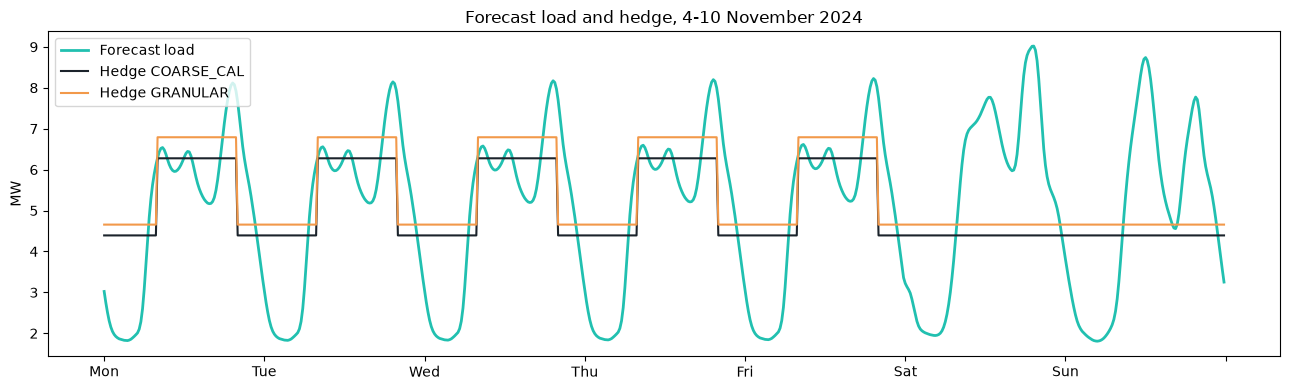

In [40]:
# Value neutrality vs volume neutrality: 
# average HPFC per MWh of load and of hedge
load = grid["total_load_mwh"]
print("Average HPFC per MWh of forecast load:", round((load * grid["hpfc"]).sum() / load.sum(), 2), "EUR/MWh")
for i in range(1, len(strategies)):
    hedge = grid["hedge_" + strategies[i].lower() + "_mwh"]
    print("Average HPFC per MWh of " + strategies[i] + " hedge:", round((hedge * grid["hpfc"]).sum() / hedge.sum(), 2), "EUR/MWh")

# chart: 
# forecast load and hedge in one week in November (Q4) in MW
week = grid[(grid["timestamp_local"] >= pd.Timestamp("2024-11-04", tz="Europe/Berlin")) & (grid["timestamp_local"] < pd.Timestamp("2024-11-11", tz="Europe/Berlin"))]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(range(len(week)), week["total_load_mwh"] * 4, color=colors[0], linewidth=2, label="Forecast load")
ax.plot(range(len(week)), week["hedge_coarse_cal_mwh"] * 4, color=colors[1], label="Hedge COARSE_CAL")
ax.plot(range(len(week)), week["hedge_granular_mwh"] * 4, color=colors[2], label="Hedge GRANULAR")
# one tick per day (96 quarter-hours)
ax.set_xticks(range(0, 7 * 96 + 1, 96))
ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun", ""])
ax.set_title("Forecast load and hedge, 4-10 November 2024")
ax.set_ylabel("MW")
ax.legend()
plt.tight_layout()
# save the figure as pdf for the report
plt.savefig("s3_hedge_week.pdf", bbox_inches="tight")
plt.show()

**Value vs volume neutrality**

Value neutrality does not mean volume neutrality. Both hedges buy more energy than the forecast load (44 504 and 44 079 vs 43 000 MWh). The reason is that the load is concentrated in expensive hours. One MWh of load is worth 81.25 EUR/MWh on average under the HPFC, while one MWh of the flatter hedge is only worth 78.50 (COARSE_CAL) or 79.26 (GRANULAR) EUR/MWh. To reach the same value the hedge must therefore contain more MWh than the load.

**Remaining risks**

- Shape risk: The hedge only has two levels per block (Base, and Base + Peak), so it cannot follow the load inside the day. The chart shows it is too high at night and too low in the evening peak after 20:00 and on weekends, which are not Peak hours. These differences (about 12 000 MWh) must be bought or sold at the Day-Ahead price (Stage 4).
- Price risk on the residual: The residual is settled at the realised Day-Ahead price, not at the HPFC, so it is still exposed to price spikes such as December 2024.
- Model risk in the HPFC: The positions are sized with an HPFC built from a 2019–2022 shape. If 2024 prices have a different hourly pattern, the hedge is valued on the wrong curve.
- Volume risk: The hedge is sized on the forecast, so it does not protect against the customers using more or less than forecast. This is settled at reBAP in Stage 5.

## Stage 4: Shape the forecast position Day-Ahead

### 4.1 Day-ahead residual per strategy

In [41]:
# Add the realised Day-Ahead price to grid
# first I check that every row is the same quarter-hour in both tables
print("Same timestamps in grid and day_ahead:", (grid["timestamp_utc"] == day_ahead["timestamp_utc"]).all())
grid["da_price"] = day_ahead["day_ahead_price_eur_mwh"]

# day-ahead residual for every strategy: 
# R_t = L_t - H_t (MWh)
for i in range(len(strategies)):
    name = strategies[i].lower()
    grid["residual_" + name + "_mwh"] = grid["total_load_mwh"] - grid["hedge_" + name + "_mwh"]

# energy bought (R > 0) and sold (R < 0) and net in the day-ahead market over the year
residual_summary = pd.DataFrame(index=strategies)
for i in range(len(strategies)):
    residual = grid["residual_" + strategies[i].lower() + "_mwh"]
    residual_summary.loc[strategies[i], "buy_mwh"] = residual[residual > 0].sum()
    residual_summary.loc[strategies[i], "sell_mwh"] = residual[residual < 0].sum()
    residual_summary.loc[strategies[i], "net_mwh"] = residual.sum()
print(residual_summary.round(2))

Same timestamps in grid and day_ahead: True
             buy_mwh  sell_mwh   net_mwh
UNHEDGED    43000.00      0.00  43000.00
COARSE_CAL   5628.16  -7131.97  -1503.82
GRANULAR     5452.98  -6532.16  -1079.18


The futures are financial contracts so they do not change what the customers need. The company schedules the full forecast load day-ahead and the part not covered by the hedge (R_t = L_t − H_t) is bought or sold at the realised day-ahead price. 

For UNHEDGED the hedge is 0 so the whole forecast (43 000 MWh) is bought day-ahead. For the two hedges about 5 500 MWh is bought and 6 500–7 100 MWh is sold over the year. The net residual is negative (−1 504 and −1 079 MWh) because the hedge contains more MWh than the load (Stage 3). This is fixed when the hedge is made and does not depend on the realised prices.

### 4.2 Cost of the forecast position

In [42]:
# Cost of the forecast position: 
# C_forecast = C_futures + sum(R_t * P_DA_t)

# futures cost in every quarter-hour: 
# base energy at the base price + peak energy at the peak price
for i in range(len(strategies)):
    grid["futures_cost_" + strategies[i].lower() + "_eur"] = 0.0
for j in range(len(positions)):
    name = positions.loc[j, "strategy"].lower()
    product = positions.loc[j, "block"]
    in_block = grid["block_" + name] == product
    base_cost = 0.25 * positions.loc[j, "x_base_mw"] * futures_prices.loc[product, "BASE"]
    peak_cost = 0.25 * positions.loc[j, "x_peak_mw"] * futures_prices.loc[product, "PEAK"] * grid.loc[in_block, "is_peak"]
    grid.loc[in_block, "futures_cost_" + name + "_eur"] = base_cost + peak_cost

forecast_cost = pd.DataFrame(index=strategies)
for i in range(len(strategies)):
    name = strategies[i].lower()
    # fixed futures cost
    forecast_cost.loc[strategies[i], "C_futures_eur"] = grid["futures_cost_" + name + "_eur"].sum()
    # residual bought (+) or sold (-) at the realised Day-Ahead price
    forecast_cost.loc[strategies[i], "C_residual_da_eur"] = (grid["residual_" + name + "_mwh"] * grid["da_price"]).sum()

# cost of the forecast position for all strategies = futures + day-ahead residual
forecast_cost["C_forecast_eur"] = forecast_cost["C_futures_eur"] + forecast_cost["C_residual_da_eur"]
print(forecast_cost.round(2))

            C_futures_eur  C_residual_da_eur  C_forecast_eur
UNHEDGED             0.00         3506703.99      3506703.99
COARSE_CAL     3493701.73          -42735.09      3450966.64
GRANULAR       3493705.92          -42198.57      3451507.34


The futures cost is fixed on 29 September 2023. 
- Each MW of Base is paid at the Base price in every quarter-hour of its block. 
- Each MW of Peak at the Peak price in the Peak quarter-hours

The hedged strategies pay about 3.49 million EUR for futures and then earn a little by selling their extra volume day-ahead. In total the forecast position costs about 3.45 million EUR for both hedges, against 3.51 million EUR for UNHEDGED. The futures cost for COARSE_CAL is 4 EUR lower than its HPFC value in Stage 3 because the HPFC reproduces the CAL quote only up to rounding (Stage 2.3).

### 4.3 Check through the financial representation

In [43]:
# Check: 
# C_forecast = sum(L_t * P_DA_t) - Pi_futures
# Pi_futures = value of the hedge energy at the day-ahead price - fixed futures cost
load_at_da = (grid["total_load_mwh"] * grid["da_price"]).sum()
for i in range(len(strategies)):
    name = strategies[i].lower()
    pi_futures = (grid["hedge_" + name + "_mwh"] * grid["da_price"]).sum() - forecast_cost.loc[strategies[i], "C_futures_eur"]
    forecast_cost.loc[strategies[i], "Pi_futures_eur"] = pi_futures
    forecast_cost.loc[strategies[i], "C_forecast_check_eur"] = load_at_da - pi_futures

# difference between the two ways of writing the cost, for all strategies at once (should be 0)
forecast_cost["difference_eur"] = forecast_cost["C_forecast_eur"] - forecast_cost["C_forecast_check_eur"]
# turn the table so each strategy is one column
print(forecast_cost[["C_forecast_eur", "C_forecast_check_eur", "difference_eur", "Pi_futures_eur"]].round(2).T)

                        UNHEDGED  COARSE_CAL    GRANULAR
C_forecast_eur        3506703.99  3450966.64  3451507.34
C_forecast_check_eur  3506703.99  3450966.64  3451507.34
difference_eur              0.00        0.00        0.00
Pi_futures_eur              0.00    55737.35    55196.65


The same cost can be written as the load bought at the day-ahead price minus the gain on the futures (Pi_futures). Both ways give the same cost for every strategy, so the calculation is consistent. 

The futures gained about 55 000 EUR in 2024 because day-ahead prices on average ended up higher than the futures prices for the hedged hours. For UNHEDGED there are no futures, giving Pi_futures = 0.

### 4.4 What a positive and negative residual mean

       UNHEDGED  COARSE_CAL  GRANULAR
month                                
1        4266.0       479.0    -129.0
2        3898.0       367.0     -94.0
3        3930.0       192.0     -22.0
4        3548.0      -111.0     225.0
5        3368.0      -420.0     -71.0
6        3073.0      -541.0    -209.0
7        3082.0      -706.0    -207.0
8        3144.0      -621.0    -126.0
9        3199.0      -438.0      40.0
10       3591.0      -201.0    -467.0
11       3726.0        89.0    -164.0
12       4173.0       408.0     145.0


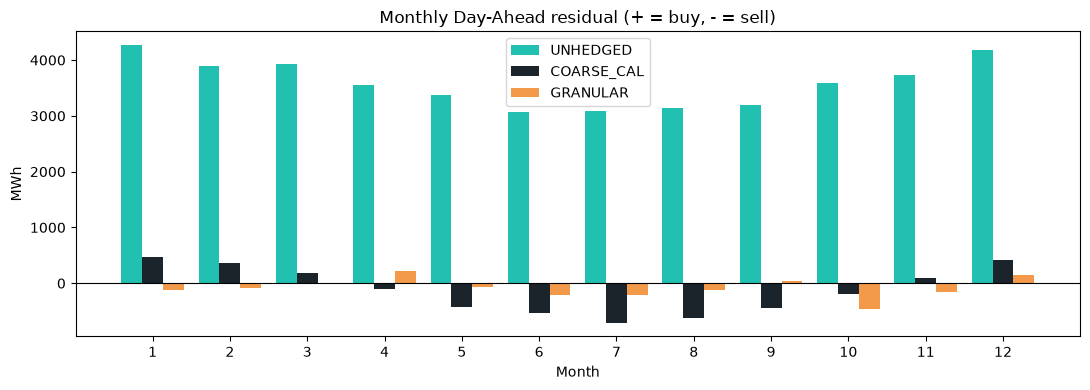

In [44]:
# day-ahead residual per month and strategy in MWh -> + = bought and - = sold
monthly_residual = pd.DataFrame()
for i in range(len(strategies)):
    monthly_residual[strategies[i]] = grid.groupby("month")["residual_" + strategies[i].lower() + "_mwh"].sum()
# all three are printed
print(monthly_residual.round(0))

# chart: 
# one group of bars per month, one bar per strategy
fig, ax = plt.subplots(figsize=(11, 4))
for i in range(len(strategies)):
    ax.bar(monthly_residual.index + (i - 1) * 0.27, monthly_residual[strategies[i]], width=0.27, color=colors[i], label=strategies[i])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_title("Monthly Day-Ahead residual (+ = buy, - = sell)")
ax.set_xlabel("Month")
ax.set_ylabel("MWh")
ax.legend()
plt.tight_layout()
plt.show()

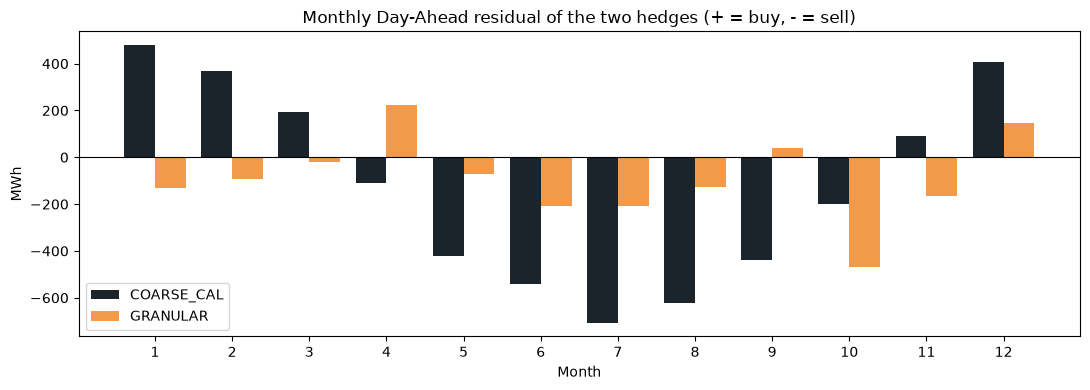

In [45]:
# chart
# only the two hedges because the chart above is hard to read for the hedges
hedged = ["COARSE_CAL", "GRANULAR"]
hedged_colors = [colors[1], colors[2]]
# COARSE_CAL = left. GRANULAR = right
offsets = [-0.2, 0.2]
fig, ax = plt.subplots(figsize=(11, 4))
for i in range(len(hedged)):
    ax.bar(monthly_residual.index + offsets[i], monthly_residual[hedged[i]], width=0.4, color=hedged_colors[i], label=hedged[i])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_title("Monthly Day-Ahead residual of the two hedges (+ = buy, - = sell)")
ax.set_xlabel("Month")
ax.set_ylabel("MWh")
ax.legend()
plt.tight_layout()
# save figure as pdf for report
plt.savefig("s4_monthly_residual.pdf", bbox_inches="tight")
plt.show()

Positive residual: 

the hedge covers less than the forecast load, so the missing energy must be bought in the day-ahead market. This is a cost when the price is positive and an income when it is negative

Negative residual: 

the hedge covers more than the load. Since the futures are financial, the extra energy is not needed and is sold back in the day-ahead market which reduces the cost. If the day-ahead price is negative selling costs money.


UNHEDGED is the extreme case: the residual is positive in every quarter-hour, since everything is bought day-ahead. COARSE_CAL uses one flat position for the whole year, so it buys in winter when the load is high and sells in summer when the load is low. GRANULAR has a separate position per month or quarter, so it follows the seasons and has no clear seasonal pattern in the residual.


In [46]:
# For negative day-ahead prices buying gives income and selling costs money
# cost = volume x price
negative_price = grid["da_price"] < 0
print("Hours with a negative Day-Ahead price:", negative_price.sum() / 4)

for i in range(len(strategies)):
    residual = grid["residual_" + strategies[i].lower() + "_mwh"]
    # quarter-hours with a negative price where the strategy buys (R > 0) or sells (R < 0)
    buying = negative_price & (residual > 0)
    selling = negative_price & (residual < 0)
    # Day-Ahead cost in these quarter-hours
    cost_buying = (residual[buying] * grid.loc[buying, "da_price"]).sum()
    cost_selling = (residual[selling] * grid.loc[selling, "da_price"]).sum()
    print(strategies[i] + ": bought " + str(round(residual[buying].sum())) + " MWh, cost " + str(round(cost_buying)) + " EUR | sold " + str(round(-residual[selling].sum())) + " MWh, cost " + str(round(cost_selling)) + " EUR")

Hours with a negative Day-Ahead price: 457.0
UNHEDGED: bought 2313 MWh, cost -29979 EUR | sold 0 MWh, cost 0 EUR
COARSE_CAL: bought 365 MWh, cost -6086 EUR | sold 299 MWh, cost 1180 EUR
GRANULAR: bought 473 MWh, cost -7966 EUR | sold 220 MWh, cost 543 EUR


## Stage 5: Settle the volume deviation

### 5.1 Imbalance volume

In [47]:
# Add the actual load and reBAP to grid
# check that every row is the same quarter-hour in all three tables
print("Same timestamps:", (grid["timestamp_utc"] == actual_load["timestamp_utc"]).all() and (grid["timestamp_utc"] == imbalance["timestamp_utc"]).all())
grid["actual_load_mwh"] = actual_load["total_actual_mwh"]
grid["rebap"] = imbalance["imbalance_price_eur_mwh"]

# imbalance volume, same for every strategy:
# I_t = A_t - L_t (MWh)
grid["imbalance_mwh"] = grid["actual_load_mwh"] - grid["total_load_mwh"]

print("Actual load:  ", round(grid["actual_load_mwh"].sum(), 1), "MWh")
print("Forecast load:", round(grid["total_load_mwh"].sum(), 1), "MWh")
print("Net imbalance:", round(grid["imbalance_mwh"].sum(), 1), "MWh")
print("Quarter-hours short (I > 0):", (grid["imbalance_mwh"] > 0).sum())
print("Quarter-hours long (I < 0): ", (grid["imbalance_mwh"] < 0).sum())

# net imbalance per month (MWh): + = short, - = long
print("\nNet imbalance per month (MWh):")
print(grid.groupby("month")["imbalance_mwh"].sum().round(1))

Same timestamps: True
Actual load:   43138.0 MWh
Forecast load: 43000.0 MWh
Net imbalance: 138.0 MWh
Quarter-hours short (I > 0): 19221
Quarter-hours long (I < 0):  15915

Net imbalance per month (MWh):
month
1     16.8
2     35.3
3     37.5
4      8.4
5    -42.6
6     35.2
7      6.4
8    -40.3
9     31.7
10    87.6
11     9.5
12   -47.6
Name: imbalance_mwh, dtype: float64


During delivery the customers use a different amount than forecast. The imbalance (I_t = A_t − L_t) is the difference between actual consumption and the day-ahead schedule, which is the forecast load for all three strategies. 

Over 2024 the customers used 43 138 MWh against a forecast of 43 000 MWh, so the portfolio was 138 MWh short in total (0.3 %). It was short in 19 221 quarter-hours and long in 15 915, and net short in 9 of 12 months (long only in May, August and December).

### 5.2 Imbalance settlement, premium and final procurement cost

In [48]:
# Imbalance settlement, imbalance premium and final procurement cost

# C_imb = sum(I_t * reBAP_t), the same for every strategy
c_imb = (grid["imbalance_mwh"] * grid["rebap"]).sum()
# Premium_imb = sum(I_t * (reBAP_t - P_DA_t)): 
# the extra cost of settling at reBAP instead of day-ahead
premium_imb = (grid["imbalance_mwh"] * (grid["rebap"] - grid["da_price"])).sum()
# the same imbalance valued at the day-ahead price
imbalance_at_da = (grid["imbalance_mwh"] * grid["da_price"]).sum()
print("C_imb:", round(c_imb, 2), "EUR")
print("  = imbalance at Day-Ahead price:", round(imbalance_at_da, 2), "EUR")
print("  + imbalance premium:           ", round(premium_imb, 2), "EUR")

# final procurement cost: 
# C_final = C_futures + C_residual_DA + C_imb
final_cost = forecast_cost[["C_futures_eur", "C_residual_da_eur", "C_forecast_eur"]].copy()
final_cost["C_imb_eur"] = c_imb
final_cost["Premium_imb_eur"] = premium_imb
final_cost["C_final_eur"] = final_cost["C_futures_eur"] + final_cost["C_residual_da_eur"] + final_cost["C_imb_eur"]
print()
print(final_cost.round(2).T)

C_imb: 30503.84 EUR
  = imbalance at Day-Ahead price: 16914.6 EUR
  + imbalance premium:            13589.24 EUR

                     UNHEDGED  COARSE_CAL    GRANULAR
C_futures_eur            0.00  3493701.73  3493705.92
C_residual_da_eur  3506703.99   -42735.09   -42198.57
C_forecast_eur     3506703.99  3450966.64  3451507.34
C_imb_eur            30503.84    30503.84    30503.84
Premium_imb_eur      13589.24    13589.24    13589.24
C_final_eur        3537207.83  3481470.48  3482011.18


The imbalance is settled at the reBAP price and costs 30 504 EUR in 2024. About 16 915 EUR of this is what the extra energy would have cost at the day-ahead price. The imbalance premium is 13 589 EUR, the extra cost of settling at reBAP instead of day-ahead. 

The premium is positive, which means the portfolio was on average in the costly direction: short when reBAP was above day-ahead, and long when reBAP was below day-ahead. The imbalance cost and the premium are exactly the same for all three strategies. The final cost is 3.54 million EUR for UNHEDGED and 3.48 million EUR for both hedged strategies.

### 5.3 Interpretation: sign of the imbalance and the risk the hedge does not remove

**Positive imbalance (short):**

the customers used more than scheduled. Missing energy is bought at reBAP,so positive = cost and negative = income 

**Negative imbalance (long):**

the customers used less than scheduled, so the extra energy is sold at reBAP. This gives income when reBAP is positive, but becomes a cost when reBAP is negative, which happened in 6 962 quarter-hours in 2024 (Exhibit 4).

**Why the imbalance is the same for all strategies:**

the Day-Ahead schedule is the forecast load L_t under every strategy. The futures only change how the forecast is paid for (futures price vs Day-Ahead price), not how much is scheduled. So I_t = A_t − L_t does not depend on the hedge at all.

**The risk the hedge does not remove:** volume or forecast risk. 

The futures are sized on the forecast, which is only known before delivery, while the actual consumption is only known afterwards. No combination of Base and Peak futures can hedge an error that is not known in advance. Only a better forecast, or products that follow the actual volume such as options (Oum, Oren and Deng, 2006), could reduce this cost.


## Stage 6: Advise management

### 6.1 Monthly procurement cost and price

Monthly average procurement price (EUR/MWh):
       UNHEDGED  COARSE_CAL  GRANULAR
month                                
1         81.39       81.51     80.11
2         64.88       79.04     63.62
3         66.60       78.44     65.36
4         63.29       79.29     66.15
5         66.42       80.55     66.29
6         74.49       80.97     67.30
7         66.94       81.74     74.88
8         79.92       77.41     72.95
9         78.91       78.49     74.24
10        90.99       80.56    110.16
11       121.72       82.77    108.39
12       119.36       86.48    110.70


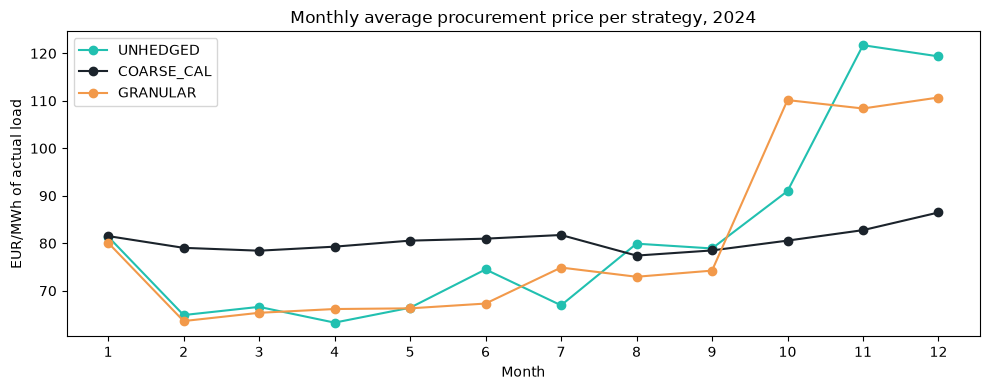

In [49]:
# procurement cost in every quarter-hour and strategy: 
# futures + day-ahead residual + imbalance
for i in range(len(strategies)):
    name = strategies[i].lower()
    grid["cost_" + name + "_eur"] = (grid["futures_cost_" + name + "_eur"]
                                     + grid["residual_" + name + "_mwh"] * grid["da_price"]
                                     + grid["imbalance_mwh"] * grid["rebap"])

# monthly cost and monthly average procurement price (EUR per MWh of actual load)
monthly_actual = grid.groupby("month")["actual_load_mwh"].sum()
monthly_cost = pd.DataFrame()
monthly_price = pd.DataFrame()
for i in range(len(strategies)):
    monthly_cost[strategies[i]] = grid.groupby("month")["cost_" + strategies[i].lower() + "_eur"].sum()
    monthly_price[strategies[i]] = monthly_cost[strategies[i]] / monthly_actual
print("Monthly average procurement price (EUR/MWh):")
print(monthly_price.round(2))

# chart: 
# monthly procurement price per strategy
fig, ax = plt.subplots(figsize=(10, 4))
for i in range(len(strategies)):
    ax.plot(monthly_price.index, monthly_price[strategies[i]], color=colors[i], marker="o", label=strategies[i])
ax.set_xticks(range(1, 13))
ax.set_title("Monthly average procurement price per strategy, 2024")
ax.set_xlabel("Month")
ax.set_ylabel("EUR/MWh of actual load")
ax.legend()
plt.tight_layout()
plt.savefig("s6_monthly_price.pdf", bbox_inches="tight")   # save the figure as PDF for the report
plt.show()

UNHEDGED follows the day-ahead market, from about 63 EUR/MWh in spring to about 120 EUR/MWh in November and December. 

COARSE_CAL is almost flat (77–86 EUR/MWh), because one annual price is paid all year. 

GRANULAR follows the futures prices of each block: low in January–September and high in October–December, because the Q4 futures were expensive. This seasonal pattern was already locked in on 29 September 2023, so it was known in advance.

### 6.2 Cost and risk comparison of the strategies

In [50]:
# Cost and risk comparison of the three strategies
# every row = a strategy

total_actual = grid["actual_load_mwh"].sum()
# final cost of each strategy as one column
final_costs = final_cost["C_final_eur"]

comparison = pd.DataFrame(index=strategies)
# cost
comparison["final_cost_eur"] = final_costs
comparison["final_price_eur_mwh"] = final_costs / total_actual
comparison["saving_vs_unhedged_eur"] = final_costs["UNHEDGED"] - final_costs
# cost stability over the months (one value per column in monthly_price)
comparison["monthly_price_std"] = monthly_price.std()
comparison["monthly_price_range"] = monthly_price.max() - monthly_price.min()
# remaining exposure and hedge quality 
comparison["abs_residual_da_mwh"] = hedge_check["abs_residual_mwh"]
comparison["residual_rmse_mwh"] = hedge_check["rmse_mwh"]
# cost of forecast error 
comparison["imbalance_cost_eur"] = final_cost["C_imb_eur"]
comparison["imbalance_premium_eur"] = final_cost["Premium_imb_eur"]

# turn the table so each strategy is one column
print(comparison.round(2).T)

                          UNHEDGED  COARSE_CAL    GRANULAR
final_cost_eur          3537207.83  3481470.48  3482011.18
final_price_eur_mwh          82.00       80.71       80.72
saving_vs_unhedged_eur        0.00    55737.35    55196.65
monthly_price_std            20.15        2.43       18.56
monthly_price_range          58.43        9.08       47.08
abs_residual_da_mwh       43000.00    12760.13    11985.15
residual_rmse_mwh             1.32        0.44        0.42
imbalance_cost_eur        30503.84    30503.84    30503.84
imbalance_premium_eur     13589.24    13589.24    13589.24


Both hedges end up about 55 000 EUR (1.6 %) cheaper than UNHEDGED, at almost the same price (80.71 and 80.72 vs 82.00 EUR/MWh). This saving is a backtest result for 2024, not proof that hedging makes money. It happened because day-ahead prices ended up higher than the futures on average. 

COARSE_CAL has the most stable monthly price, but only because it spreads one annual price over all months. 

GRANULAR leaves the least open volume (11 985 MWh) and follows the load best (RMSE 0.42). The imbalance cost is the same for all three strategies (Stage 5).

### 6.3 How the cost changes as each stage is added

            1_futures  2_plus_day_ahead  3_plus_imbalance
UNHEDGED          0.0         3506704.0         3537208.0
COARSE_CAL  3493702.0         3450967.0         3481470.0
GRANULAR    3493706.0         3451507.0         3482011.0


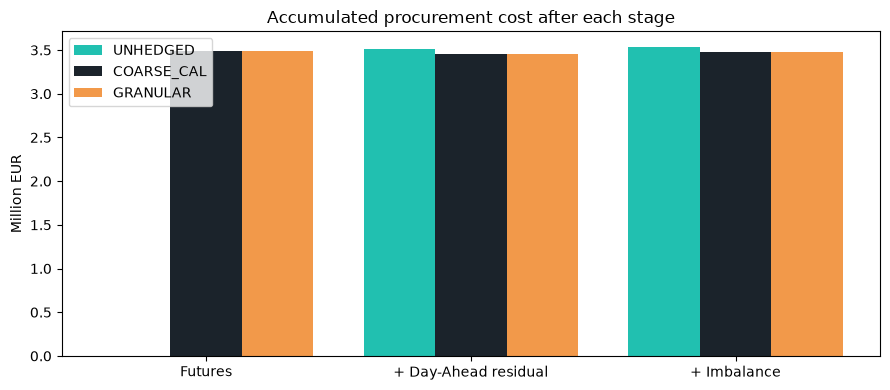

In [51]:
# How the cost changes as each stage is added (EUR)
cost_by_stage = pd.DataFrame(index=strategies)
cost_by_stage["1_futures"] = final_cost["C_futures_eur"]
cost_by_stage["2_plus_day_ahead"] = final_cost["C_forecast_eur"]
cost_by_stage["3_plus_imbalance"] = final_cost["C_final_eur"]
print(cost_by_stage.round(0))

# chart: 
# one group per stage, one bar per strategy (million EUR)
stage_columns = ["1_futures", "2_plus_day_ahead", "3_plus_imbalance"]
fig, ax = plt.subplots(figsize=(9, 4))
for i in range(len(strategies)):
    positions_x = []
    for k in range(len(stage_columns)):
        positions_x.append(k + (i - 1) * 0.27)
    ax.bar(positions_x, cost_by_stage.loc[strategies[i], stage_columns] / 1000000, width=0.27, color=colors[i], label=strategies[i])
ax.set_xticks(range(3))
ax.set_xticklabels(["Futures", "+ Day-Ahead residual", "+ Imbalance"])
ax.set_title("Accumulated procurement cost after each stage")
ax.set_ylabel("Million EUR")
ax.legend()
plt.tight_layout()
plt.savefig("s6_stage_cost.pdf", bbox_inches="tight")   # save the figure as PDF for the report
plt.show()

For the hedged strategies, most of the cost (about 3.49 million EUR) is fixed with the futures. The day-ahead step then lowers the cost a little, because the extra hedge volume is sold, and the imbalance adds about 30 500 EUR. For UNHEDGED nothing is fixed in advance: the whole cost comes from the day-ahead market, plus the same imbalance cost.

### 6.4 Tail risk of the open position (VaR and CVaR)

In [52]:
# Tail risk of the open position
# cost surprise = the part of the cost that was not known on 29 Sep 2023:
# residual priced at (realised day-ahead - HPFC) + the whole imbalance cost
day = grid["timestamp_local"].dt.date
tail_risk = pd.DataFrame(index=strategies)
for i in range(len(strategies)):
    name = strategies[i].lower()
    # surprise after the Day-Ahead stage: only the open residual at (Day-Ahead - HPFC)
    daily_da_surprise = (grid["residual_" + name + "_mwh"] * (grid["da_price"] - grid["hpfc"])).groupby(day).sum()
    # surprise after the imbalance stage: Day-Ahead surprise + imbalance cost
    grid["surprise_" + name + "_eur"] = grid["residual_" + name + "_mwh"] * (grid["da_price"] - grid["hpfc"]) + grid["imbalance_mwh"] * grid["rebap"]
    # one value per day
    daily_surprise = grid.groupby(day)["surprise_" + name + "_eur"].sum()
    # 95 % VaR:
    # the daily surprise cost that is only exceeded on 5 % of the days
    var_95 = daily_surprise.quantile(0.95)
    tail_risk.loc[strategies[i], "total_surprise_eur"] = daily_surprise.sum()
    # daily standard deviation after each stage (how the risk changes when imbalance is added)
    tail_risk.loc[strategies[i], "std_daily_after_day_ahead_eur"] = daily_da_surprise.std()
    tail_risk.loc[strategies[i], "std_daily_after_imbalance_eur"] = daily_surprise.std()
    tail_risk.loc[strategies[i], "VaR_95_daily_eur"] = var_95
    # 95 % CVaR (= Expected Shortfall):
    # the average surprise cost on the worst 5 % of days
    tail_risk.loc[strategies[i], "CVaR_95_daily_eur"] = daily_surprise[daily_surprise >= var_95].mean()
    tail_risk.loc[strategies[i], "worst_day_eur"] = daily_surprise.max()
    tail_risk.loc[strategies[i], "worst_day"] = str(daily_surprise.idxmax())

# turn the table so each strategy is one column
print(tail_risk.round(0).T)

                                 UNHEDGED  COARSE_CAL    GRANULAR
total_surprise_eur                43502.0    -12231.0    -11695.0
std_daily_after_day_ahead_eur      4307.0       658.0       539.0
std_daily_after_imbalance_eur      4535.0       977.0       839.0
VaR_95_daily_eur                   4679.0      1048.0       886.0
CVaR_95_daily_eur                 10605.0      2402.0      2047.0
worst_day_eur                     48327.0      8393.0      8125.0
worst_day                      2024-12-12  2024-12-11  2024-06-03


To measure risk, I look at the part of the cost that was not known when the hedge was made: the open residual priced at the difference between the realised Day-Ahead price and the HPFC, plus the imbalance cost.

**How the risk changes with each stage:** 

the futures stage has no surprise, because its cost was fixed on 29 September 2023. The Day-Ahead stage adds price risk on the open residual, and the imbalance stage adds volume risk. For UNHEDGED almost all the daily risk comes from the Day-Ahead step. For the hedged strategies the Day-Ahead risk is small, so the imbalance step adds a large part of the risk that is left.

**Tail risk:** 

for UNHEDGED the surprise is large. On the worst 5 % of days it costs on average 10 605 EUR per day (CVaR), and on 12 December alone 48 327 EUR. Both hedges reduce this by about 80 %, and GRANULAR has the lowest risk on every measure (daily std, VaR and CVaR). COARSE_CAL is weaker in winter, because its flat annual position under-hedges the high winter load (Stage 4), which shows on 11 December.

### 6.5 Recommendation

I recommend GRANULAR (M01, M02, M03 + Q2, Q3, Q4, Base and Peak).

The purpose of the hedge is to limit losses from adverse price movements, not to make money. The strategy should therefore be judged on risk as well as cost.

**Cost:** 

It has practically the same realised cost as COARSE_CAL (the difference is 541 EUR, or 0.02 %) and is 55 000 EUR cheaper than UNHEDGED in 2024. The lowest cost alone is not a reason to choose a hedge, since it depends on one realised year.

**Risk:** 

It leaves the smallest open volume (11 985 MWh), follows the load best (RMSE 0.42), and has the lowest tail risk (daily VaR 886 EUR and CVaR 2 047 EUR, against 1 048 and 2 402 for COARSE_CAL and 4 679 and 10 605 for UNHEDGED).

**Seasons:**
It follows the seasonal load with a separate position per month or quarter. COARSE_CAL over-hedges in summer and under-hedges in winter, when prices are highest.

**Cost stability:** 

GRANULAR's monthly price varies more than COARSE_CAL's, but this variation comes from the futures prices and was known in advance. The company can therefore plan for it, for example in its customer prices.

**Remaining risk:**

None of the strategies removes the volume risk (Stage 5).

## Stage 7: Interpret a severe price event

I use the event from Exhibit 4.5: 11-12 December 2024. 
These were the two days with the highest average Day-Ahead price in 2024. All results come from the grid built in Stages 1–6, so there is no new optimisation.

### 7.1 Select the event

In [53]:
# days with the highest average day-ahead price in 2024
grid["date"] = grid["timestamp_local"].dt.date
daily_da_price = grid.groupby("date")["da_price"].agg(["mean", "max", "min"])
print("Top 5 days by average Day-Ahead price (EUR/MWh):")
print(daily_da_price.sort_values("mean", ascending=False).head(5).round(2))

# the event: 
# 11-12 December 2024 in local time (2 days x 96 quarter-hours)
event = grid[(grid["timestamp_local"] >= "2024-12-11") & (grid["timestamp_local"] < "2024-12-13")].copy()
print("\nQuarter-hours in the event:", len(event))

# realised prices in the event compared with the price in the HPFC
event_prices = event.groupby("date")[["da_price", "hpfc", "rebap"]].agg(["mean", "max"])
print("\nPrices on the event days (EUR/MWh):")
print(event_prices.round(2))
print("\nHours with Day-Ahead price above 500 EUR/MWh:", (event["da_price"] > 500).sum() / 4)
print("Lowest reBAP in the event:", round(event["rebap"].min(), 2), "EUR/MWh")

Top 5 days by average Day-Ahead price (EUR/MWh):
              mean     max     min
date                              
2024-12-12  395.34  936.28  107.35
2024-12-11  266.54  445.08  106.17
2024-11-06  231.09  820.11   95.47
2024-12-04  182.47  287.76  110.19
2024-12-13  178.47  284.21  114.95

Quarter-hours in the event: 192

Prices on the event days (EUR/MWh):
           da_price            hpfc           rebap         
               mean     max    mean     max    mean      max
date                                                        
2024-12-11   266.54  445.08  103.88  150.86  994.84  5359.16
2024-12-12   395.34  936.28  103.88  150.86  233.12   931.41

Hours with Day-Ahead price above 500 EUR/MWh: 9.0
Lowest reBAP in the event: 33.5 EUR/MWh


The event covers two days and 12 December is the most expensive day of the year. On 29 September 2023 the HPFC valued these days at about 104 EUR/MWh. The realised Day-Ahead price was roughly 2.5–4 times higher, and above 500 EUR/MWh for 9 hours. reBAP was even more extreme on 11 December. These are real market outcomes and I keep them in the data.

### 7.2 Price, load, hedge and residual exposure

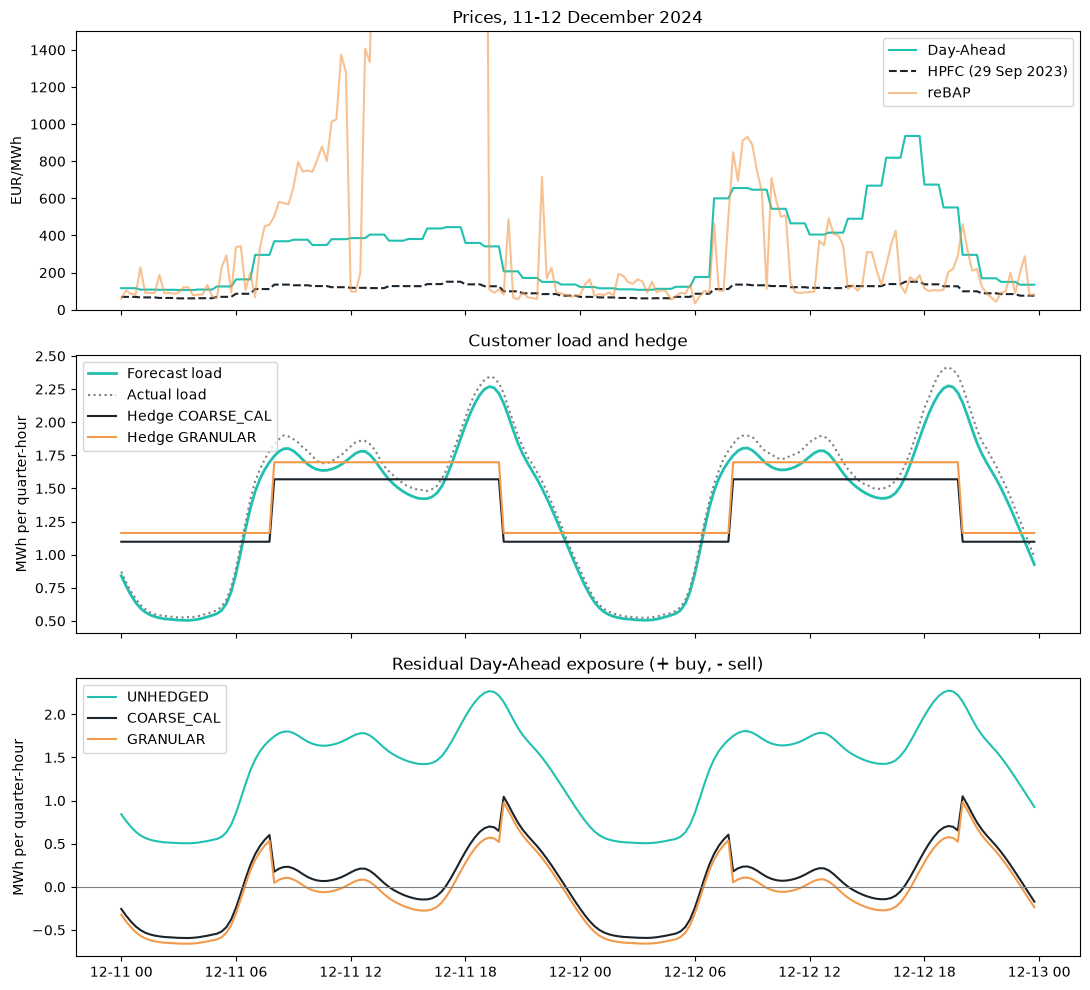

In [54]:
# price, load, hedge and residual exposure in the event
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

# top: 
# prices
axes[0].plot(event["timestamp_local"], event["da_price"], color="#21C0B0", label="Day-Ahead")
axes[0].plot(event["timestamp_local"], event["hpfc"], color="#1B232B", linestyle="--", label="HPFC (29 Sep 2023)")
axes[0].plot(event["timestamp_local"], event["rebap"], color="#F2994A", alpha=0.6, label="reBAP")
axes[0].set_ylim(0, 1500)                  # reBAP peak of 5,359 EUR/MWh is cut so the Day-Ahead price is visible
axes[0].set_ylabel("EUR/MWh")
axes[0].set_title("Prices, 11-12 December 2024")
axes[0].legend()

# middle: 
# forecast load, actual load and hedge
axes[1].plot(event["timestamp_local"], event["total_load_mwh"], color="#21C0B0", linewidth=2, label="Forecast load")
axes[1].plot(event["timestamp_local"], event["actual_load_mwh"], color="grey", linestyle=":", label="Actual load")
axes[1].plot(event["timestamp_local"], event["hedge_coarse_cal_mwh"], color=colors[1], label="Hedge COARSE_CAL")
axes[1].plot(event["timestamp_local"], event["hedge_granular_mwh"], color=colors[2], label="Hedge GRANULAR")
axes[1].set_ylabel("MWh per quarter-hour")
axes[1].set_title("Customer load and hedge")
axes[1].legend()

# bottom: 
# residual day-ahead exposure R = L - H (+ = buy, - = sell)
for i in range(len(strategies)):
    axes[2].plot(event["timestamp_local"], event["residual_" + strategies[i].lower() + "_mwh"], color=colors[i], label=strategies[i])
axes[2].axhline(0, color="grey", linewidth=0.8)
axes[2].set_ylabel("MWh per quarter-hour")
axes[2].set_title("Residual Day-Ahead exposure (+ buy, - sell)")
axes[2].legend()

plt.tight_layout()
# save the figure as pdf for the report
plt.savefig("s7_event.pdf", bbox_inches="tight")   
plt.show()

UNHEDGED has its whole load open in the day-ahead market, including the evening peak when prices are highest. The two hedges cover the base level all day plus a Peak layer from 08:00 to 20:00. The open position that remains is a shape residual. At night the hedge is above the load, so the company sells. In the evening ramp around 18:00–21:00 it has to buy, and the largest buy is right after 20:00 when the Peak layer stops. GRANULAR has a slightly higher hedge level in December because its Q4 position is larger than the CAL position.

### 7.3 How the event affected procurement cost

In [55]:
# what the event cost each strategy
event_cost = pd.DataFrame(index=strategies)
for i in range(len(strategies)):
    name = strategies[i].lower()
    residual = event["residual_" + name + "_mwh"]
    event_cost.loc[strategies[i], "forecast_load_mwh"] = event["total_load_mwh"].sum()
    event_cost.loc[strategies[i], "hedge_mwh"] = event["hedge_" + name + "_mwh"].sum()
    event_cost.loc[strategies[i], "residual_bought_mwh"] = residual[residual > 0].sum()
    event_cost.loc[strategies[i], "residual_sold_mwh"] = residual[residual < 0].sum()
    # cost at the HPFC on 29 Sep 2023: 
    # futures + open position at the HPFC
    event_cost.loc[strategies[i], "cost_at_hpfc_eur"] = (event["futures_cost_" + name + "_eur"] + residual * event["hpfc"]).sum()
    # realised cost: 
    # futures + day-ahead residual + imbalance
    event_cost.loc[strategies[i], "realised_cost_eur"] = event["cost_" + name + "_eur"].sum()
    # cost surprise split into the day-ahead part and the imbalance part
    event_cost.loc[strategies[i], "surprise_day_ahead_eur"] = (residual * (event["da_price"] - event["hpfc"])).sum()
    event_cost.loc[strategies[i], "surprise_imbalance_eur"] = (event["imbalance_mwh"] * event["rebap"]).sum()
    event_cost.loc[strategies[i], "surprise_total_eur"] = event["surprise_" + name + "_eur"].sum()
    # average procurement price in the event in EUR per MWh of actual load
    event_cost.loc[strategies[i], "price_eur_mwh"] = event["cost_" + name + "_eur"].sum() / event["actual_load_mwh"].sum()
print("Event 11-12 December 2024:")
print(event_cost.round(1).T)

# open position in the most expensive quarter-hours = day-ahead above 300 EUR/MWh
expensive = event[event["da_price"] > 300]
print("\nQuarter-hours with Day-Ahead above 300 EUR/MWh:", len(expensive))
for i in range(len(strategies)):
    name = strategies[i].lower()
    print(strategies[i], "- net residual:", round(expensive["residual_" + name + "_mwh"].sum(), 1), "MWh")

Event 11-12 December 2024:
                        UNHEDGED  COARSE_CAL  GRANULAR
forecast_load_mwh          264.6       264.6     264.6
hedge_mwh                    0.0       256.0     274.7
residual_bought_mwh        264.6        36.9      26.3
residual_sold_mwh            0.0       -28.4     -36.5
cost_at_hpfc_eur         29931.3     22369.1   29615.4
realised_cost_eur       109537.4     37599.0   39772.8
surprise_day_ahead_eur   71571.4      7195.3    2122.7
surprise_imbalance_eur    8034.7      8034.7    8034.7
surprise_total_eur       79606.1     15230.0   10157.3
price_eur_mwh              395.4       135.7     143.6

Quarter-hours with Day-Ahead above 300 EUR/MWh: 100
UNHEDGED - net residual: 172.8 MWh
COARSE_CAL - net residual: 17.8 MWh
GRANULAR - net residual: 5.1 MWh


The two days cost UNHEDGED about 80,000 EUR more than its value at the HPFC on the hedge date. That is more than the saving from hedging over the whole year (Stage 6.2). The hedges cut the Day-Ahead surprise by about 90% (COARSE_CAL) and 97% (GRANULAR). When the price was above 300 EUR/MWh, GRANULAR had only about 5 MWh open.

On these two days GRANULAR has a higher realised cost than COARSE_CAL. The reason is that GRANULAR bought December at the higher Q4 futures price, which was known and locked in 2023. That is a planned cost, not a surprise. The surprise is the part that shows the risk, and it is lowest for GRANULAR.

With the hedge, imbalance becomes the largest part of the surprise (about 8,000 EUR). The net imbalance was small, but reBAP reached 5,359 EUR/MWh on 11 December. None of the strategies can hedge this, because it comes from load forecast errors and not from the futures position.

### 7.4 Sensitivity: larger or longer price spike

In [56]:
# simple sensitivity: what if the price spike was larger or lasted longer?
# The day-ahead surprise is linear: sum(R_t * (P_DA_t - HPFC_t)).
# Larger spike: the price gap above the HPFC multiplied by 2 or 3.
# Longer event: the same 2-day pattern repeated (10 days = 5 times, 20 days = 10 times).
# Imbalance is left out because it depends on the forecast error and reBAP, not on the hedge.
sensitivity = pd.DataFrame(index=strategies)
for i in range(len(strategies)):
    surprise = event_cost.loc[strategies[i], "surprise_day_ahead_eur"]
    sensitivity.loc[strategies[i], "as_observed_eur"] = surprise
    sensitivity.loc[strategies[i], "spike_x2_eur"] = 2 * surprise
    sensitivity.loc[strategies[i], "spike_x3_eur"] = 3 * surprise
    sensitivity.loc[strategies[i], "10_days_eur"] = 5 * surprise
    sensitivity.loc[strategies[i], "20_days_eur"] = 10 * surprise
    # the longest case as a share of the annual procurement cost
    sensitivity.loc[strategies[i], "20_days_share_of_annual_cost_pct"] = 100 * 10 * surprise / final_cost.loc[strategies[i], "C_final_eur"]
print("Extra Day-Ahead cost compared with the HPFC (EUR):")
print(sensitivity.round(1).T)

Extra Day-Ahead cost compared with the HPFC (EUR):
                                  UNHEDGED  COARSE_CAL  GRANULAR
as_observed_eur                    71571.4      7195.3    2122.7
spike_x2_eur                      143142.9     14390.6    4245.3
spike_x3_eur                      214714.3     21585.9    6368.0
10_days_eur                       357857.2     35976.4   10613.4
20_days_eur                       715714.4     71952.8   21226.7
20_days_share_of_annual_cost_pct      20.2         2.1       0.6


The extra cost grows linearly with both the size and the length of the spike, so the open volume decides everything. If a similar winter event had lasted 20 days, UNHEDGED would have paid about 716,000 EUR more, which is 20% of its annual procurement cost. The hedged strategies stay at 2.1% for coarse_cal and 0.6% for granular. This is a simple stress test. It assumes the same load and price pattern every day and leaves out imbalance.

### 7.5 Conclusion: liquidity and remaining risks

**Without a hedge** 

Customers pay a fixed price, but UNHEDGED buys its whole load on the spot market. Each spot purchase has to be paid shortly after delivery, while revenue from customers comes in at the fixed price over the billing period. A two-day spike like this one is expensive, but a company of this size can absorb it. It is not a bankruptcy event on its own. The danger is duration. If high prices last for days or weeks, the cash drain grows quickly (7.4) and can use up the company's liquidity before new prices can be passed on to customers. Oum describe a Texas retailer that went bankrupt after a three-day ice storm left it exposed to spot prices. The risk is exactly this persistence, not a single expensive hour.

**With a hedge** 

Most of the price risk is gone, but some risks remain:

**Shape risk:** 

A Base + Peak block cannot follow the load curve. The evening ramp, especially after 20:00, is still bought at spot prices.

**Volume / imbalance risk:** 

Forecast errors are settled at reBAP, which can spike far more than Day-Ahead. This was the largest remaining cost in the event.

**Liquidity risk from the futures:** 

Exchange futures need collateral and daily margin payments, so falling prices can also cause cash outflows.

**Load and horizon risk:** 

The hedge only covers 2024 and the forecast load. If customers leave or consumption changes, the company becomes over- or under-hedged. The next year still has to be bought at the prices that apply then.

GRANULAR gave the best protection during the event, which supports the recommendation in Stage 6.

## Section 13: Assumptions and limitations

In close the briefing I listed four simplifications. Here I go back to them and use the results to show how each one could change the hedge, the procurement cost or the recommendation, and in which direction.

### 13.1 Fixed standard-profile forecast -> volume risk

In [57]:
# Volume risk = imbalance cost compared with the cost gap between the two hedges
# final cost of each strategy as one column
final_costs = final_cost["C_final_eur"]
cost_gap = final_costs["GRANULAR"] - final_costs["COARSE_CAL"]
print("Cost gap GRANULAR - COARSE_CAL:", round(cost_gap, 2), "EUR")
print("Imbalance cost (all strategies):", round(final_cost.loc["GRANULAR", "C_imb_eur"], 2), "EUR")
print("Imbalance premium (all strategies):", round(final_cost.loc["GRANULAR", "Premium_imb_eur"], 2), "EUR")
# positive correlation = the portfolio tends to be short when prices are high
print("Correlation imbalance vs Day-Ahead price:", round(grid["imbalance_mwh"].corr(grid["da_price"]), 3))
print("Premium/cost gap:", round(final_cost.loc["GRANULAR", "Premium_imb_eur"] / cost_gap, 1))

Cost gap GRANULAR - COARSE_CAL: 540.7 EUR
Imbalance cost (all strategies): 30503.84 EUR
Imbalance premium (all strategies): 13589.24 EUR
Correlation imbalance vs Day-Ahead price: 0.103
Premium/cost gap: 25.1


The forecast is a fixed SLP with no weather or change in customer numbers. Imbalance cost is the same for every strategy, so it does not change the ranking. It is still large compared with the difference between the hedges: the imbalance premium alone is about 25 times the cost gap between GRANULAR and COARSE_CAL. The imbalance is weakly positively correlated with the day-ahead price, so the portfolio is short slightly more often when power is expensive, as it was in the December event. A forecast without weather probably understates this. 

**Direction:** 

real imbalance costs and volume risk are likely higher than in our result, for all strategies. A better load forecast could matter as much as the choice between the two hedges.

### 13.2 Historical shape -> shape risk in the HPFC

                 da_relative  hpfc_relative
timestamp_local                            
3                       0.82           0.77
8                       1.23           1.17
13                      0.60           0.84
19                      1.55           1.32


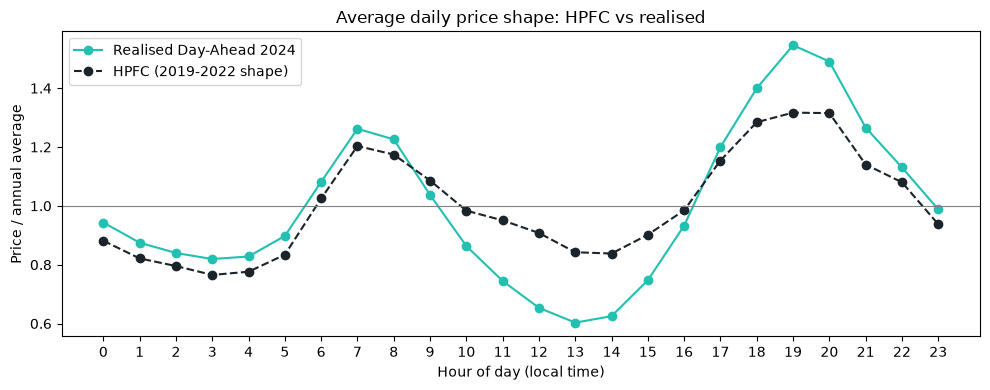

In [58]:
# Shape risk: realised daily price shape in 2024 compared with the shape in the HPFC
# ex-post check: uses 2024 prices that were not known on 29 Sep 2023
hourly_shape = grid.groupby(grid["timestamp_local"].dt.hour)[["da_price", "hpfc"]].mean()
hourly_shape["da_relative"] = hourly_shape["da_price"] / grid["da_price"].mean()     # 1 = annual average
hourly_shape["hpfc_relative"] = hourly_shape["hpfc"] / grid["hpfc"].mean()
print(hourly_shape.loc[[3, 8, 13, 19], ["da_relative", "hpfc_relative"]].round(2))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly_shape.index, hourly_shape["da_relative"], color="#21C0B0", marker="o", label="Realised Day-Ahead 2024")
ax.plot(hourly_shape.index, hourly_shape["hpfc_relative"], color="#1B232B", linestyle="--", marker="o", label="HPFC (2019-2022 shape)")
ax.axhline(1, color="grey", linewidth=0.8)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Price / annual average")
ax.set_title("Average daily price shape: HPFC vs realised")
ax.legend()
plt.tight_layout()
plt.savefig("s13_shape.pdf", bbox_inches="tight")   # save the figure as PDF for the report
plt.show()

The HPFC uses the 2019–2022 shape. In 2024 the midday dip was much deeper and the evening peak higher, which fits more solar power in the system. The HPFC therefore overvalued midday hours and undervalued the evening. This matters in two ways:
1) The Peak product (08–20) covers midday hours that became cheaper, while hours 20–21 are left out even though they were among the most expensive of the day.
2) The open shape residual that remains after hedging is mostly bought in the evening ramp (Stage 7), which is exactly where the HPFC underestimated prices.

**Direction:** 

the cost and risk of the remaining shape position are likely higher than the HPFC suggested when the hedge was made, and the gap could grow as more solar is added. This does not change which strategy is best. It does mean the value-neutral hedge volumes rest on a price shape that is already out of date.

### 13.3 Simplified futures market -> trading costs and cash needs

In [59]:
# Trading costs: extra cost per MWh that would remove GRANULAR's cost difference
granular_volume = grid["hedge_granular_mwh"].sum()
print("Futures volume GRANULAR:", round(granular_volume, 1), "MWh")
print("Futures volume COARSE_CAL:", round(grid["hedge_coarse_cal_mwh"].sum(), 1), "MWh")
print("Trades: GRANULAR", 2 * 6, "vs COARSE_CAL", 2 * 1)          # Base + Peak in each product
print("Cost gap per MWh of GRANULAR futures:", round(cost_gap / granular_volume, 3), "EUR/MWh")

Futures volume GRANULAR: 44079.2 MWh
Futures volume COARSE_CAL: 44503.8 MWh
Trades: GRANULAR 12 vs COARSE_CAL 2
Cost gap per MWh of GRANULAR futures: 0.012 EUR/MWh


The model has no bid–ask spread, fees, lot sizes or margin. The cost gap is only 0.012 EUR/MWh of traded futures, so the two hedges cost practically the same. Trading costs would make GRANULARs small cost disadvantage larger.

**Direction:** 

trading costs make both hedges more expensive, and GRANULAR more so. Margin payments on the futures add a cash need that the model ignores (see Stage 7). The recommendation should therefore rest on risk reduction, not on the small difference in total cost.

### 13.4 Only Base and Peak futures, no options or intraday trading

The hedge can only fix a price for a fixed block of energy. After hedging, GRANULAR still has about 12,000 MWh of absolute day-ahead residual (Stage 3), the full imbalance, and a worst surprise day of about 8,100 EUR (Stage 6). Options, as in Oum, Oren and Deng (2006), could reduce the volume and tail risk, but the premium would raise the expected cost. Intraday trading could reduce part of the imbalance premium, but it has its own costs and was left out on purpose. 

**Direction:** 

with more instruments the remaining risk would be lower and the expected cost probably slightly higher. GRANULAR is the best choice among the products we were allowed to use. It is not an optimal hedge in general.

### 13.5 Summary

A summary of the assumptions I made in close the briefing and their effect and likely directions: 

Fixed SLP forecast:
- Main effect: Imbalance cost and volume risk
- Likely direction: Understated for all strategies, ranking unchanged

Historical 2019-2022 shape
- Main effect: Value of evening residual, fit of the Peak block
- Likely direction: Shape risk understated, especially in the evening

Simplified futures market
- Main effect: Trading costs, margin cash needs
- Likely direction: Both hedges more expensive. GRANULARs small cost disadvantage becomes larger

Only base/peak futures
- Main effect: Remaining volume and tail risk
- Likely direction: Lower risk but higher cost with options or intraday trading

The whole evaluation also rests on one realised year. COARSE_CAL's slightly lower cost in 2024 is one outcome, not a systematic advantage. The recommendation for GRANULAR is based on its lower residual exposure and smaller cost surprise, which do not depend on the price path in a single year.